# Melanoma Mortality, Incidence, Dermatology Access and Rurality
## County-level geospatial multivariate analysis

**Environment:** Google Colab (Python) · cross-sectional, 2019–2023

---

### The analytic problem this notebook is built around

Melanoma mortality in a population decomposes as

> **mortality rate  ≈  incidence rate  ×  case fatality**

So a mortality model that *controls for incidence* is really estimating **case
fatality** — how lethal the disease is once it is being found. That is the right
target for an access question, because a dermatologist cannot stop melanoma from
occurring; they can find it earlier and change how it ends.

But incidence sits in **two causal roles at once**:

| Role | Path | Implication |
|---|---|---|
| **Confounder** | UV exposure, skin type → incidence → mortality | *Must* control for it |
| **Mediator** | Access → more screening → more recorded incidence | Controlling for it is **over-adjustment** |

Conditioning on a mediator can bias the estimate and even flip its sign. Since
recorded incidence is genuinely both things, no single model is trustworthy alone.
This notebook therefore reports **four complementary specifications** and asks you to
read them together:

| Model | Question it answers |
|---|---|
| **A. Incidence model** | Does access raise *detection*? (tests the mediator path directly) |
| **B. Mortality, unadjusted** | Total association, detection and survival mixed together |
| **C. Mortality, incidence-adjusted** | Case fatality — deaths per case found |
| **D. Mortality-to-incidence ratio (MIR)** | Same target as C, but as a ratio; the standard population proxy for cancer survival |

**MIR leads.** MIR = mortality ÷ incidence is the conventional population-level
survival proxy in cancer health-services research. It answers the case-fatality
question by construction rather than by conditioning, so it sidesteps the mediator
problem instead of arguing about it.

> If A shows access ↑ incidence **and** D shows access ↓ MIR, the coherent reading is
> *more detection, earlier stage, better survival* — not that dermatologists cause
> melanoma.

### Rurality

Entered **two ways, as separate specifications** (never in the same model — they are
nested and would be collinear):

- `rural_cat` — 3 levels: metro (RUCC 1–3), nonmetro (RUCC 4–7), completely rural (RUCC 8–9)
- `metro` — binary

Each is also run with a **dermatologist × rurality interaction**, which is the policy
question: does having a dermatologist matter *more* where they are scarce?

### Two things verified in your data that change the analysis

1. **`melanoma_mortality_rate` is CRUDE; `ageadjustedrate` is AGE-ADJUSTED.**
   Age structure therefore still inflates mortality in older counties but has been
   removed from incidence. Every mortality model is re-run against a derived **crude**
   incidence rate as a consistency check. Treat this as a live limitation, not a
   footnote.
2. **111 exactly-duplicated rows (all Georgia).** A many-to-one merge upstream
   duplicated 111 Georgia counties. They are dropped here, but **fix it upstream** —
   any un-deduplicated analysis double-weights part of Georgia.

### Coverage

Counties with suppressed incidence were dropped before you received the file. That
loss is **not random** — it tracks small, rural populations, which are exactly the
counties an access study cares about. Step 6 quantifies the damage by rurality class.

## Step 1 · Install packages

Run once per Colab session (~90 s).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess, sys, importlib

PKGS = ["geopandas", "shapely", "libpysal", "esda", "mapclassify",
        "pyproj", "spreg", "statsmodels"]
need = []
for p in PKGS:
    try:
        importlib.import_module(p)
    except ImportError:
        need.append(p)

if need:
    print("Installing:", ", ".join(need))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *need])
    print("Done. If Colab prompts for a runtime restart, restart and re-run from here.")
else:
    print("All packages already present.")

All packages already present.


## Step 2 · Configuration

**Set `csv_path` to your file in Google Drive.** The cell mounts Drive first; if the
path is wrong it lists nearby `.csv` files so you can copy the right one.

In [3]:
CONFIG = {
    # ---- WHERE YOUR FILE LIVES -----------------------------------------
    # Default assumes Google Drive. Change the folder to match yours.
    "csv_path":    "/content/drive/MyDrive/Current Research/3-Student/a-Danielle/derm_melanomamortinc_ruc_data-ready-update.csv",
    "mount_drive": True,          # set False if the file is uploaded to /content

    # ---- COLUMN NAMES (match your file exactly) ------------------------
    "fips":        "fips",                      # 5-digit county FIPS
    "state":       "state",
    "county":      "county",

    # dermatology
    "derm_count":  "dermatologists",
    "derm_rate":   "dermatology_rate",          # per 100k (2019 county pop)
    "any_derm":    "anyderm",                   # binary 0/1  (no underscore)

    # mortality
    "mort_rate":   "melanoma_mortality_rate",   # CRUDE deaths per 100k
    "mort_event":  "melanoma_deaths",
    "mort_denom":  "pop",

    # incidence
    "inc_rate":    "ageadjustedrate",           # AGE-ADJUSTED cases per 100k
    "inc_event":   "casecount",
    "inc_denom":   "population",

    # rurality
    "rucc":        "rucc_2013",                 # 1-9
    "rural_cat":   "rural_cat",                 # 1 metro / 2 nonmetro / 3 rural
    "metro":       "metro",                     # 1 metro / 0 nonmetro

    # weight. NOTE: the true denominator behind derm_rate (2019 county
    # population) is NOT in this file, so `pop` stands in as a county-size
    # measure for empirical-Bayes smoothing. Add the real column and point
    # "derm_denom" at it if you have it.
    "weight":      "pop",
    "derm_denom":  "pop",

    # ---- OPTIONS -------------------------------------------------------
    "drop_territories": True,
    "n_classes":        5,
    "permutations":     999,
    "random_seed":      2024,
    "out_dir":          "outputs",
    "dpi":              180,
}

import os, glob
if CONFIG["mount_drive"] and not os.path.exists("/content/drive"):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except ImportError:
        print("Not in Colab - skipping Drive mount.")

os.makedirs(CONFIG["out_dir"], exist_ok=True)

if os.path.exists(CONFIG["csv_path"]):
    print("Found data file:", CONFIG["csv_path"])
else:
    print("!! NOT FOUND:", CONFIG["csv_path"], "\n")
    roots = ["/content/drive/MyDrive", "/content"]
    hits = []
    for r in roots:
        if os.path.isdir(r):
            hits += glob.glob(os.path.join(r, "**", "*.csv"), recursive=True)[:40]
    if hits:
        print("CSV files I can see - copy the right path into CONFIG['csv_path']:")
        for h in hits[:40]:
            print("   ", h)
    else:
        print("No CSVs found. Check that Drive mounted and the folder name is right.")
print("\nOutput directory:", os.path.abspath(CONFIG["out_dir"]))

Found data file: /content/drive/MyDrive/Current Research/3-Student/a-Danielle/derm_melanomamortinc_ruc_data-ready-update.csv

Output directory: /content/outputs


## Step 3 · Imports and shared style

In [4]:
import os, io, json, zipfile, urllib.request, textwrap, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.affinity import scale as shp_scale, translate as shp_translate

warnings.filterwarnings("ignore")
np.random.seed(CONFIG["random_seed"])
mpl.rcParams.update({"figure.facecolor": "white", "savefig.facecolor": "white",
                     "font.size": 11})

CRS_ALBERS  = "EPSG:5070"
NODATA_FACE = "#e9e9ec"; NODATA_EDGE = "#c4c4cc"
ZERO_FACE   = "#f2efe6"
EDGE_COLOR  = "#ffffff"; EDGE_WIDTH = 0.08
STATE_EDGE  = "#6b6b76"; STATE_WIDTH = 0.45
INK, INK2, MUTED, GRID = "#1a1a1f", "#55555f", "#83838f", "#e6e6ea"

# Two-group categorical palette - validated for colour-vision deficiency
# (protan dE 25.1, normal dE 30.5 against a light surface)
GRP = {0: ("No dermatologist", "#c85a10"), 1: ("Has dermatologist", "#2a72c9")}

# Bivariate 3x3 (Stevens). rows = Y low->high, cols = X low->high
BIV3 = [["#e8e8e8", "#ace4e4", "#5ac8c8"],
        ["#dfb0d6", "#a5add3", "#5698b9"],
        ["#be64ac", "#8c62aa", "#3b4994"]]

# Diverging ramp for MIR: two hues + NEUTRAL grey midpoint (never a hue at the middle)
MIR_CMAP = LinearSegmentedColormap.from_list(
    "mir", ["#2166ac", "#82b3d3", "#f0f0f0", "#e8927c", "#b2182b"])

LISA_COLORS = {0: "#dcdce0", 1: "#c3272b", 2: "#7fb2d4", 3: "#2c5f9e", 4: "#e8a3a0"}
LISA_LABELS = {0: "Not significant", 1: "High–High", 2: "Low–High",
               3: "Low–Low", 4: "High–Low"}
RURAL_LABELS = {1: "Metro (RUCC 1–3)", 2: "Nonmetro (RUCC 4–7)",
                3: "Completely rural (RUCC 8–9)"}
RURAL_COLORS = {1: "#dfe7ef", 2: "#7fa6c4", 3: "#2d5575"}   # ordered -> sequential

print("geopandas", gpd.__version__, "| matplotlib", mpl.__version__)

geopandas 1.1.4 | matplotlib 3.10.0


## Step 4 · Load and validate

In [5]:
df_raw = pd.read_csv(CONFIG["csv_path"])
print(f"Loaded {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns\n")

needed = ["fips", "derm_count", "derm_rate", "any_derm", "mort_rate", "mort_event",
          "mort_denom", "inc_rate", "inc_event", "inc_denom", "rucc", "rural_cat",
          "metro", "weight", "derm_denom"]
missing = {k: CONFIG[k] for k in needed if CONFIG[k] not in df_raw.columns}
if missing:
    raise KeyError("Configured columns not found in your CSV: "
                   + ", ".join(f"{k}->'{v}'" for k, v in missing.items())
                   + f"\n\nPresent: {list(df_raw.columns)}")
print("Schema OK.\n")
display(df_raw.head(3))

Loaded 2,308 rows x 22 columns

Schema OK.



,county,ageadjustedrate,casecount,population,state,county_merge,state_merge,fips,dermatologists,dermatology_rate,...,pop,melanoma_deaths,melanoma_crude,melanoma_mortality_rate,rucc_2013,_merge,anyderm,rural_cat,metro,mir
0,Autauga County,27.6,72,217483,alabama,autauga county,AL,1001,0,0.00,...,218447,10,4.58,3.3,2,Matched (3),0,1,1,0.119565
1,Baldwin County,36.0,528,1002585,alabama,baldwin county,AL,1003,7,3.14,...,1029873,38,3.69,2.5,3,Matched (3),1,1,1,0.069444
2,Barbour County,33.0,32,56116,alabama,barbour county,AL,1005,0,0.00,...,55752,2,3.59,1.7,6,Matched (3),0,2,0,0.051515


## Step 5 · De-duplicate, then derive the analysis variables

Your file contains **exactly-duplicated rows**. They come from a many-to-one merge
upstream and are all in Georgia. Dropping them here fixes this notebook but **not
your source file** — re-running any earlier analysis on the un-deduplicated data will
double-weight those counties.

In [6]:
df = df_raw.copy()

# ---- exact duplicate rows -------------------------------------------------
n_exact = int(df.duplicated().sum())
if n_exact:
    dup_states = df[df.duplicated(keep=False)][CONFIG["state"]].value_counts()
    print(f"!! {n_exact} EXACTLY duplicated rows found - dropping them.")
    print("   affected states:", ", ".join(f"{k} ({v})" for k, v in dup_states.items()))
    print("   -> fix the upstream merge; this is a many-to-one join artifact.\n")
    df = df.drop_duplicates().reset_index(drop=True)

# ---- any remaining same-FIPS rows that are NOT identical -------------------
df["FIPS"] = df[CONFIG["fips"]].astype(float).astype("int64").astype(str).str.zfill(5)
still = int(df["FIPS"].duplicated().sum())
if still:
    print(f"!! {still} FIPS still duplicated with DIFFERING values - keeping first. Inspect these:")
    display(df[df["FIPS"].duplicated(keep=False)].sort_values("FIPS").head(10))
    df = df.drop_duplicates("FIPS", keep="first").reset_index(drop=True)

print(f"Analysis rows: {len(df):,}  |  unique counties: {df['FIPS'].nunique():,}")

# ---- derived variables ----------------------------------------------------
IR, MR = CONFIG["inc_rate"], CONFIG["mort_rate"]

df["crude_incidence"] = df[CONFIG["inc_event"]] / df[CONFIG["inc_denom"]] * 1e5
df["mir"]        = df[MR] / df[IR]                     # crude mort / age-adj inc
df["mir_crude"]  = df[MR] / df["crude_incidence"]      # crude / crude (consistent)
df["log_mir"]    = np.log(df["mir"].replace(0, np.nan))
df["log_inc"]    = np.log(df[IR].replace(0, np.nan))
df["log_cinc"]   = np.log(df["crude_incidence"].replace(0, np.nan))
df["rural_lab"]  = df[CONFIG["rural_cat"]].map(RURAL_LABELS)
df["nonmetro"]   = (df[CONFIG["metro"]] == 0).astype(int)
df["rc2"]        = (df[CONFIG["rural_cat"]] == 2).astype(int)
df["rc3"]        = (df[CONFIG["rural_cat"]] == 3).astype(int)

print("\nDerived: crude_incidence, mir, mir_crude, log_mir, log_inc, log_cinc, rural_lab\n")
display(df[[IR, "crude_incidence", MR, "mir", "mir_crude"]].describe().round(3))

# ---- confirm which rates are crude vs adjusted ----------------------------
chk_m = np.abs(df[CONFIG["mort_event"]]/df[CONFIG["mort_denom"]]*1e5 - df[MR]).max()
chk_i = np.abs(df[CONFIG["inc_event"]]/df[CONFIG["inc_denom"]]*1e5 - df[IR]).max()
print(f"\nRATE TYPE CHECK")
print(f"  mortality reproduces as deaths/pop  : max diff {chk_m:.2e} "
      f"-> {'CRUDE' if chk_m < 1e-3 else 'NOT crude (adjusted)'}")
print(f"  incidence reproduces as cases/pop   : max diff {chk_i:.2e} "
      f"-> {'CRUDE' if chk_i < 1e-3 else 'NOT crude (age-adjusted)'}")
if chk_m < 1e-3 <= chk_i:
    print("  !! ASYMMETRY: crude mortality vs age-adjusted incidence.")
    print("     Age structure inflates mortality in older counties but has been")
    print("     removed from incidence. Every model below is re-run against")
    print("     crude_incidence as a consistency check.")

!! 110 EXACTLY duplicated rows found - dropping them.
   affected states: georgia (220)
   -> fix the upstream merge; this is a many-to-one join artifact.

Analysis rows: 2,198  |  unique counties: 2,198

Derived: crude_incidence, mir, mir_crude, log_mir, log_inc, log_cinc, rural_lab



,ageadjustedrate,crude_incidence,melanoma_mortality_rate,mir,mir_crude
count,2198.000,2198.000,2198.000,2198.000,2198.000
mean,30.005,42.332,2.872,0.105,0.075
std,10.016,15.798,1.417,0.058,0.043
min,6.900,9.764,0.300,0.011,0.007
25%,22.800,31.169,2.000,0.066,0.046
50%,28.600,39.499,2.700,0.093,0.067
75%,35.675,50.050,3.400,0.129,0.094
max,83.300,145.703,15.900,0.465,0.319



RATE TYPE CHECK
  mortality reproduces as deaths/pop  : max diff 1.28e+01 -> NOT crude (adjusted)
  incidence reproduces as cases/pop   : max diff 9.05e+01 -> NOT crude (age-adjusted)


## Step 6 · Who is missing, and does it bias the study?

Counties with suppressed incidence were dropped upstream. Suppression follows small
case counts, which follow small rural populations — so the missing counties are
exactly the ones an access study most wants. This cell measures the loss **by
rurality class** so the selection is stated rather than assumed away.

In [7]:
FULL_RUCC_URL = ("https://raw.githubusercontent.com/bhrutledge/"
                 "rural-urban-continuum-codes/master/data/ruralurbancodes2013.csv")

coverage = None
try:
    ref = pd.read_csv(FULL_RUCC_URL, dtype={"FIPS": str})
    ref["FIPS"] = ref["FIPS"].str.zfill(5)
    ref = ref.rename(columns={"RUCC_2013": "rucc"})[["FIPS", "rucc"]]
    ref["rural_cat"] = np.select([ref.rucc <= 3, ref.rucc <= 7], [1, 2], 3)
    ref["present"] = ref["FIPS"].isin(set(df["FIPS"]))
    coverage = (ref.groupby(ref.rural_cat.map(RURAL_LABELS))
                   .agg(us_counties=("FIPS", "size"), in_your_data=("present", "sum")))
    coverage["missing"] = coverage.us_counties - coverage.in_your_data
    coverage["pct_retained"] = (coverage.in_your_data / coverage.us_counties * 100).round(1)
    print("COVERAGE BY RURALITY (vs all US counties)\n")
    display(coverage)
    tot = coverage.us_counties.sum()
    print(f"Overall retained: {coverage.in_your_data.sum():,} / {tot:,} "
          f"({coverage.in_your_data.sum()/tot*100:.1f}%)")
    spread = coverage.pct_retained.max() - coverage.pct_retained.min()
    if spread > 10:
        print(f"\n!! Retention differs by {spread:.0f} points across rurality classes.")
        print("   Suppression is NOT random with respect to your key exposure.")
        print("   Every estimate below is conditional on being observed; rural")
        print("   effects in particular are estimated on a survivor subset.")
except Exception as e:
    print("Could not fetch the national RUCC reference (", e, ")")
    print("Falling back to an in-sample description only.\n")

print("\nIN-SAMPLE COMPOSITION")
comp = df.groupby("rural_lab").agg(
    counties=("FIPS", "size"),
    pct_with_derm=(CONFIG["any_derm"], lambda s: round(s.mean()*100, 1)),
    mean_derm_rate=(CONFIG["derm_rate"], "mean"),
    mean_incidence=(CONFIG["inc_rate"], "mean"),
    mean_mortality=(CONFIG["mort_rate"], "mean"),
    mean_MIR=("mir", "mean")).round(3)
display(comp)
comp.to_csv(os.path.join(CONFIG["out_dir"], "composition_by_rurality.csv"))

print("\nBY DERMATOLOGIST PRESENCE")
byd = df.groupby(CONFIG["any_derm"]).agg(
    counties=("FIPS", "size"),
    mean_incidence=(CONFIG["inc_rate"], "mean"),
    mean_mortality=(CONFIG["mort_rate"], "mean"),
    mean_MIR=("mir", "mean")).round(3)
byd.index = byd.index.map({0: "No dermatologist", 1: "Has dermatologist"})
display(byd)

Could not fetch the national RUCC reference ( HTTP Error 404: Not Found )
Falling back to an in-sample description only.


IN-SAMPLE COMPOSITION


,counties,pct_with_derm,mean_derm_rate,mean_incidence,mean_mortality,mean_MIR
rural_lab,,,,,,
Completely rural (RUCC 8–9),151,2.0,0.078,31.538,2.975,0.101
Metro (RUCC 1–3),1048,65.0,2.753,31.026,2.773,0.098
Nonmetro (RUCC 4–7),999,23.6,0.847,28.702,2.961,0.112



BY DERMATOLOGIST PRESENCE


,counties,mean_incidence,mean_mortality,mean_MIR
anyderm,,,,
No dermatologist,1278,29.073,2.996,0.112
Has dermatologist,920,31.298,2.700,0.095


## Step 7 · County boundaries

Tries several sources in order and **raises** if all fail — it will not quietly
degrade to something that is not a map.

In [8]:
GEOM_SOURCES = [
    ("Census TIGER cb_2023_us_county_20m",
     "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip", "shp"),
    ("Census TIGER cb_2021_us_county_20m",
     "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip", "shp"),
    ("Plotly county GeoJSON (Census boundaries)",
     "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
     "geojson"),
]

def _fetch(url, timeout=180):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read()

def load_county_geometry():
    errors = []
    for name, url, kind in GEOM_SOURCES:
        try:
            print(f"  trying {name} ...", end=" ", flush=True)
            raw = _fetch(url)
            if kind == "shp":
                os.makedirs("_geo_cache", exist_ok=True)
                zp = os.path.join("_geo_cache", os.path.basename(url))
                with open(zp, "wb") as fh:
                    fh.write(raw)
                with zipfile.ZipFile(zp) as z:
                    z.extractall("_geo_cache")
                shp = [x for x in os.listdir("_geo_cache") if x.endswith(".shp")][0]
                gg = gpd.read_file(os.path.join("_geo_cache", shp))
                gg["FIPS"] = gg["GEOID"].astype(str).str.zfill(5)
            else:
                gg = gpd.read_file(io.BytesIO(raw))
                gg["FIPS"] = gg["id"].astype(str).str.zfill(5)
            gg = gg[["FIPS", "geometry"]]
            gg = gg[gg.geometry.notna() & ~gg.geometry.is_empty].copy()
            if gg.crs is None:
                gg = gg.set_crs("EPSG:4326")
            print(f"OK ({len(gg):,} counties)")
            return gg, name
        except Exception as e:
            print("failed")
            errors.append(f"{name}: {type(e).__name__}: {e}")
    raise RuntimeError("Could not download county boundaries:\n  " + "\n  ".join(errors))

print("Downloading county boundaries...")
geo, geo_source = load_county_geometry()
print("\nUsing:", geo_source)

  trying Census TIGER cb_2023_us_county_20m ... OK (3,222 counties)

Using: Census TIGER cb_2023_us_county_20m


## Step 8 · Merge, project, reposition Alaska & Hawaii

Albers Equal Area (EPSG:5070) — Web Mercator would inflate northern counties and
misrepresent the map.

In [9]:
TERRITORIES = {"60", "66", "69", "72", "78"}

def reposition_ak_hi(g):
    g = g.copy(); st = g["FIPS"].str[:2]
    conus = g[~st.isin({"02", "15"} | TERRITORIES)]
    if conus.empty:
        return g, {}
    xmin, ymin, xmax, ymax = conus.total_bounds
    moved = {}
    def place(mask, factor, tx, ty, label):
        sub = g.loc[mask]
        if sub.empty: return
        b = sub.total_bounds
        cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
        g2 = sub.geometry.apply(lambda q: shp_scale(q, xfact=factor, yfact=factor, origin=(cx, cy)))
        nb = gpd.GeoSeries(g2, crs=g.crs).total_bounds
        g.loc[mask, "geometry"] = g2.apply(lambda q: shp_translate(q, xoff=tx-nb[0], yoff=ty-nb[1]))
        moved[label] = True
    place(st == "02", 0.35, xmin-0.06*(xmax-xmin), ymin-0.10*(ymax-ymin), "Alaska")
    place(st == "15", 1.00, xmin+0.30*(xmax-xmin), ymin-0.06*(ymax-ymin), "Hawaii")
    return g, moved

g_base = geo.copy()
if CONFIG["drop_territories"]:
    g_base = g_base[~g_base["FIPS"].str[:2].isin(TERRITORIES)].copy()

gdf, insets = reposition_ak_hi(g_base.merge(df, on="FIPS", how="left").to_crs(CRS_ALBERS))
if insets:
    print("Insets repositioned:", ", ".join(insets))

n_match = int(gdf[CONFIG["mort_rate"]].notna().sum())
orphan  = sorted(set(df["FIPS"]) - set(g_base["FIPS"]))
print(f"\nMERGE")
print(f"  your rows                : {len(df):,}")
print(f"  counties drawn           : {len(gdf):,}")
print(f"  matched (carry your data): {n_match:,}  ({n_match/len(df)*100:.1f}% of your rows)")
print(f"  drawn as 'No data'       : {len(gdf)-n_match:,}")
if orphan:
    print(f"  your FIPS with no polygon: {len(orphan)} e.g. {orphan[:8]}")
if n_match == 0:
    raise RuntimeError("Nothing matched - check that `fips` is a 5-digit county code.")
print("\nCRS:", gdf.crs.name)

Insets repositioned: Alaska, Hawaii

MERGE
  your rows                : 2,198
  counties drawn           : 3,144
  matched (carry your data): 2,198  (100.0% of your rows)
  drawn as 'No data'       : 946

CRS: NAD83 / Conus Albers


## Step 9 · Map helpers

**Zero-aware classification.** Most counties have no dermatologist. "Zero" is a
structurally different state from "a low positive rate", and quantile classification
breaks on that mass of ties — so zeros get their own class and a neutral colour
outside the sequential ramp.

In [10]:
def _fmt(v):
    if abs(v) >= 100: return f"{v:,.0f}"
    if abs(v) >= 10:  return f"{v:,.1f}"
    return f"{v:,.2f}"

def zero_aware_bins(values, k=5):
    v = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    ok = ~np.isnan(v); pos = v[ok & (v > 0)]
    has_zero = bool((ok & (v == 0)).any())
    if pos.size == 0:
        return np.array([]), has_zero
    edges = np.unique(np.percentile(pos, np.linspace(0, 100, k + 1)))
    if edges.size < 3:
        edges = np.unique(np.array([pos.min(), pos.max()]))
    return edges, has_zero

def classify(values, edges):
    v = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    out = np.full(v.shape, -1, int); ok = ~np.isnan(v)
    out[ok & (v == 0)] = 0
    pos = ok & (v > 0)
    if edges.size >= 2:
        out[pos] = np.digitize(v[pos], edges[1:-1], right=False) + 1
    return out

def add_state_outlines(g, ax):
    try:
        g.assign(_st=g["FIPS"].str[:2]).dissolve(by="_st").boundary.plot(
            ax=ax, color=STATE_EDGE, linewidth=STATE_WIDTH, zorder=5)
    except Exception:
        pass

def _frame(title, subtitle):
    # figure-level text: aspect="equal" shrinks the axes box, so ax.set_title drifts
    fig, ax = plt.subplots(1, 1, figsize=(13.5, 8.4))
    fig.text(.045, .955, title, fontsize=17, fontweight="bold", ha="left", va="top", color=INK)
    fig.text(.045, .908, "\n".join(textwrap.wrap(subtitle, 105)), fontsize=10.5,
             color=INK2, ha="left", va="top", linespacing=1.4)
    return fig, ax

def _finish(fig, ax, fname):
    ax.set_axis_off(); ax.set_aspect("equal")
    plt.subplots_adjust(left=.02, right=.98, top=.885, bottom=.02)
    p = os.path.join(CONFIG["out_dir"], fname)
    fig.savefig(p, dpi=CONFIG["dpi"], facecolor="white")
    print("  saved ->", p)
    plt.show()

def _legend(ax, handles, title, x=0.635):
    lg = ax.legend(handles=handles, title=title, loc="lower left", frameon=False,
                   fontsize=9.5, title_fontsize=10, handlelength=1.6, handleheight=1.1,
                   labelspacing=.62, borderaxespad=0, bbox_to_anchor=(x, 0.015))
    lg.get_title().set_fontweight("bold"); lg._legend_box.align = "left"
    return lg

def univariate_map(col, title, subtitle, legend_title, cmap, zero_label,
                   fname, fmt=_fmt, legend_x=0.635, diverging=False, center=None):
    if diverging:
        v = pd.to_numeric(gdf[col], errors="coerce")
        ok = v.notna()
        qs = np.nanpercentile(v[ok], [10, 30, 50, 70, 90])
        edges = np.concatenate([[np.nanmin(v[ok])], qs, [np.nanmax(v[ok])]])
        edges = np.unique(edges)
        cols = [to_hex(cmap(t)) for t in np.linspace(0, 1, len(edges) - 1)]
        idx = np.digitize(v.to_numpy(float), edges[1:-1], right=False)
        face = [NODATA_FACE if not o else cols[min(int(i), len(cols)-1)]
                for o, i in zip(ok, idx)]
        h = []
        for i in range(len(edges) - 1):
            lab = (f"{fmt(edges[i])} – {fmt(edges[i+1])}" if i < len(edges)-2
                   else f"{fmt(edges[i])}+")
            n = int(((idx == i) & ok).sum())
            h.append(Patch(facecolor=cols[i], edgecolor="white", lw=.5, label=f"{lab}  ({n:,})"))
    else:
        edges, has_zero = zero_aware_bins(gdf[col], CONFIG["n_classes"])
        cls = classify(gdf[col], edges)
        npos = max(edges.size - 1, 0)
        ramp = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        cols = [to_hex(ramp(t)) for t in np.linspace(0.22, 0.95, npos)] if npos else []
        face = [NODATA_FACE if c == -1 else ZERO_FACE if c == 0
                else cols[min(c-1, npos-1)] for c in cls]
        h = []
        if has_zero:
            h.append(Patch(facecolor=ZERO_FACE, edgecolor="#b9b3a2", lw=.5,
                           label=f"{zero_label}  ({int((cls==0).sum()):,})"))
        for i in range(npos):
            lab = (f"{fmt(edges[i])} – {fmt(edges[i+1])}" if i < npos-1
                   else f"{fmt(edges[i])}+")
            h.append(Patch(facecolor=cols[i], edgecolor="white", lw=.5,
                           label=f"{lab}  ({int((cls==i+1).sum()):,})"))
        ok = cls != -1

    fig, ax = _frame(title, subtitle)
    gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(gdf, ax)
    n_nd = int((~pd.Series(ok)).sum())
    if n_nd:
        h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                       label=f"No data / suppressed  ({n_nd:,})"))
    _legend(ax, h, legend_title, legend_x)
    _finish(fig, ax, fname)

def categorical_map(col, labels, colors, title, subtitle, legend_title, fname, legend_x=0.60):
    v = pd.to_numeric(gdf[col], errors="coerce")
    face = [colors.get(int(x), NODATA_FACE) if pd.notna(x) else NODATA_FACE for x in v]
    fig, ax = _frame(title, subtitle)
    gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(gdf, ax)
    cnt = v.value_counts()
    h = [Patch(facecolor=colors[k], edgecolor="white", lw=.5,
               label=f"{labels[k]}  ({int(cnt.get(k,0)):,})") for k in sorted(labels)]
    if v.isna().any():
        h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                       label=f"No data / suppressed  ({int(v.isna().sum()):,})"))
    _legend(ax, h, legend_title, legend_x)
    _finish(fig, ax, fname)

print("Map helpers ready.")

Map helpers ready.


## Step 10 · Univariate maps — dermatology access

  saved -> outputs/map_01_derm_count.png


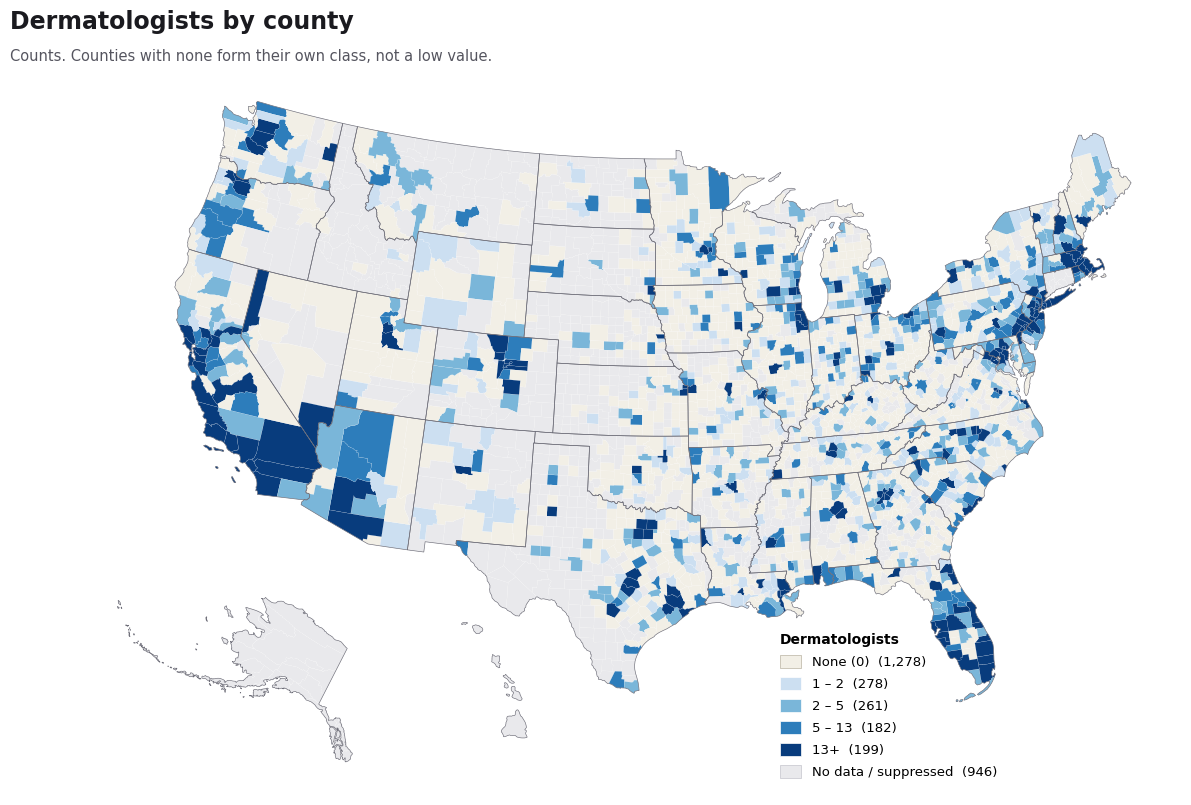

  saved -> outputs/map_02_derm_rate.png


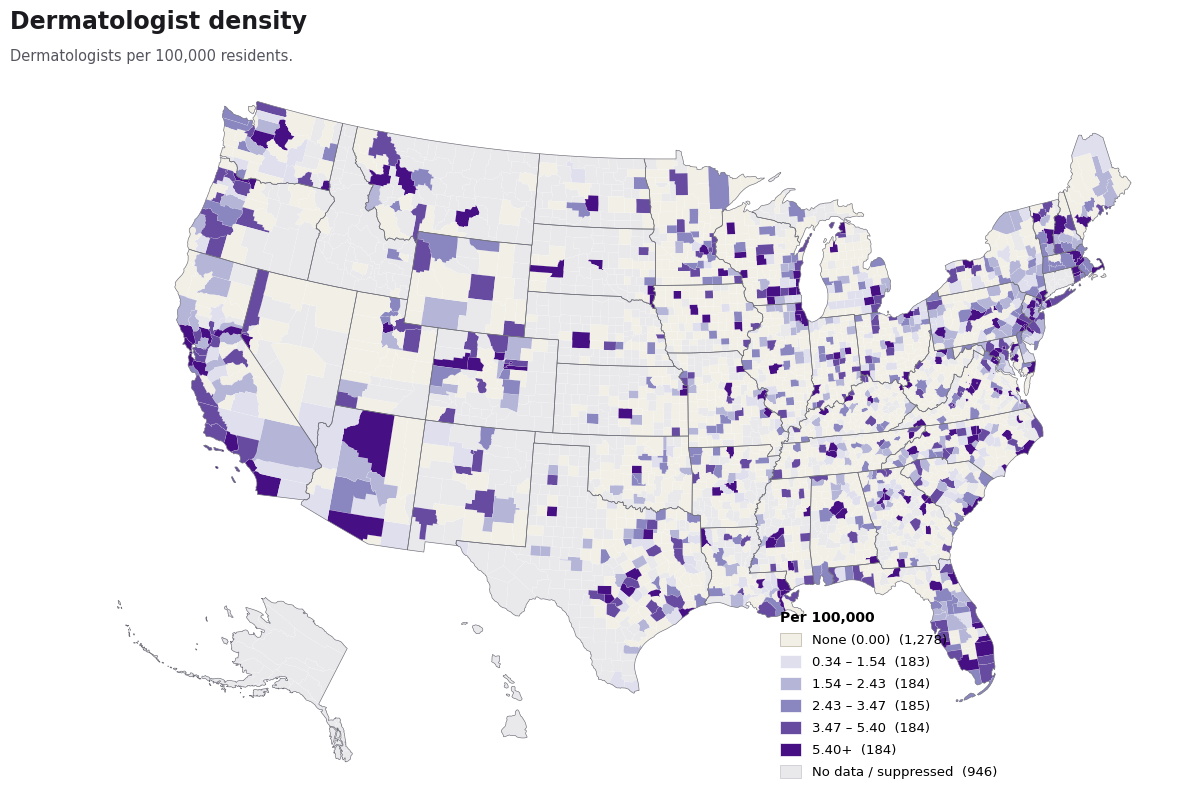

  saved -> outputs/map_03_any_derm.png


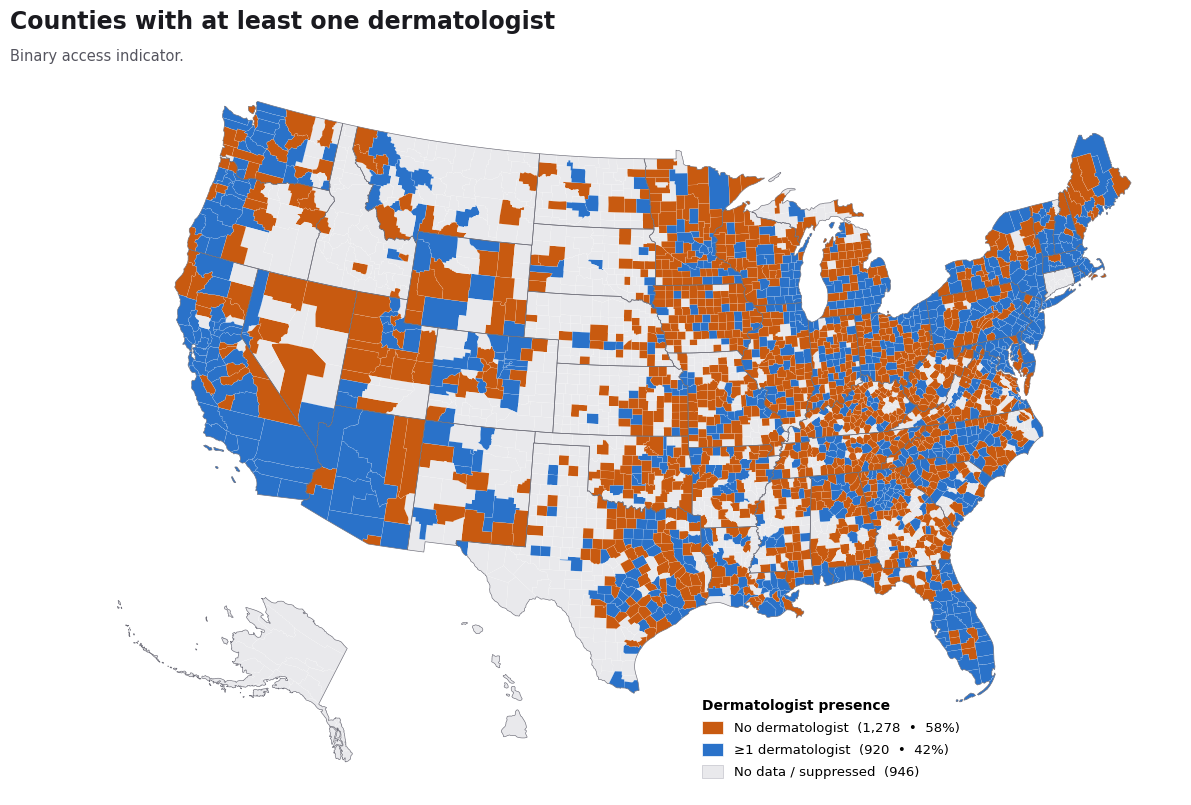

In [11]:
univariate_map(CONFIG["derm_count"], "Dermatologists by county",
               "Counts. Counties with none form their own class, not a low value.",
               "Dermatologists", "Blues", "None (0)",
               "map_01_derm_count.png", fmt=lambda v: f"{v:,.0f}")

univariate_map(CONFIG["derm_rate"], "Dermatologist density",
               "Dermatologists per 100,000 residents.",
               "Per 100,000", "Purples", "None (0.00)", "map_02_derm_rate.png")

v = pd.to_numeric(gdf[CONFIG["any_derm"]], errors="coerce")
face = np.where(v.isna(), NODATA_FACE, np.where(v > 0, GRP[1][1], GRP[0][1]))
n0, n1 = int((v == 0).sum()), int((v > 0).sum()); tot = max(n0+n1, 1)
fig, ax = _frame("Counties with at least one dermatologist",
                 "Binary access indicator.")
gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
add_state_outlines(gdf, ax)
h = [Patch(facecolor=GRP[0][1], edgecolor="white", lw=.5,
           label=f"No dermatologist  ({n0:,}  •  {n0/tot*100:.0f}%)"),
     Patch(facecolor=GRP[1][1], edgecolor="white", lw=.5,
           label=f"≥1 dermatologist  ({n1:,}  •  {n1/tot*100:.0f}%)")]
if v.isna().any():
    h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                   label=f"No data / suppressed  ({int(v.isna().sum()):,})"))
_legend(ax, h, "Dermatologist presence", x=0.565)
_finish(fig, ax, "map_03_any_derm.png")

## Step 11 · Univariate maps — disease burden and survival

  saved -> outputs/map_04_incidence.png


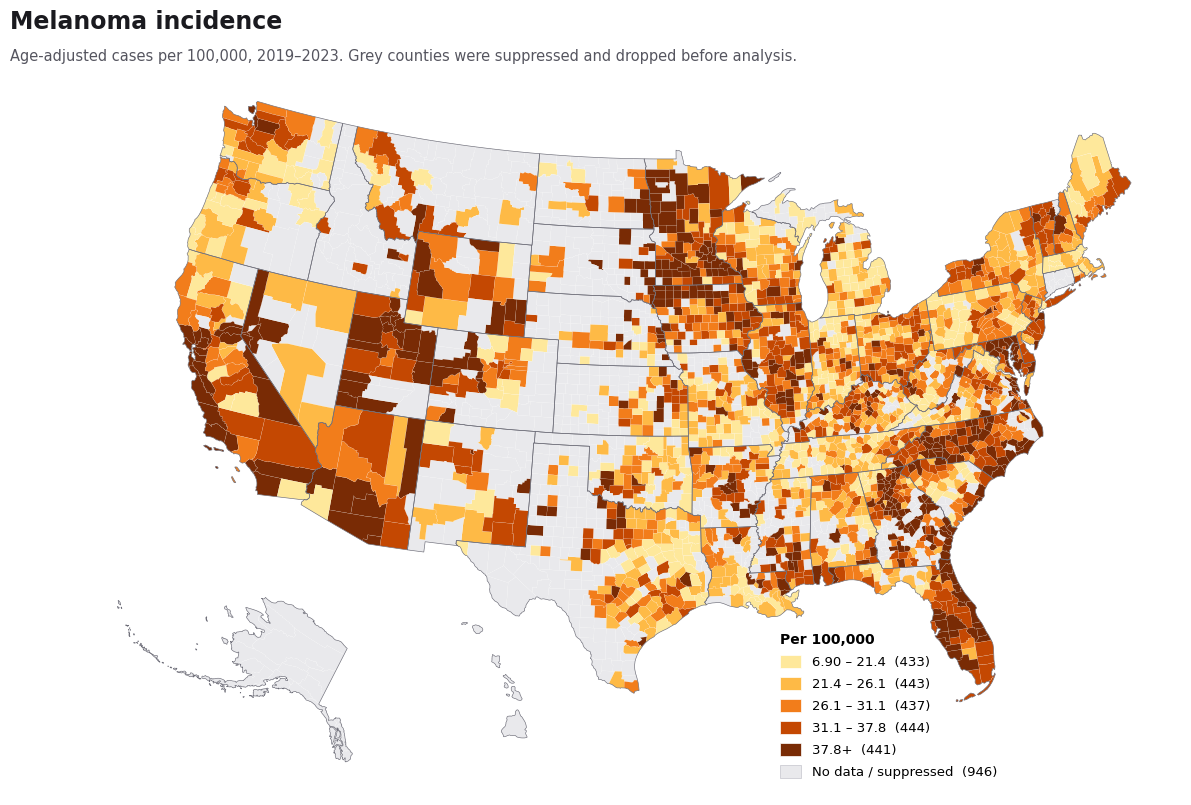

  saved -> outputs/map_05_mortality.png


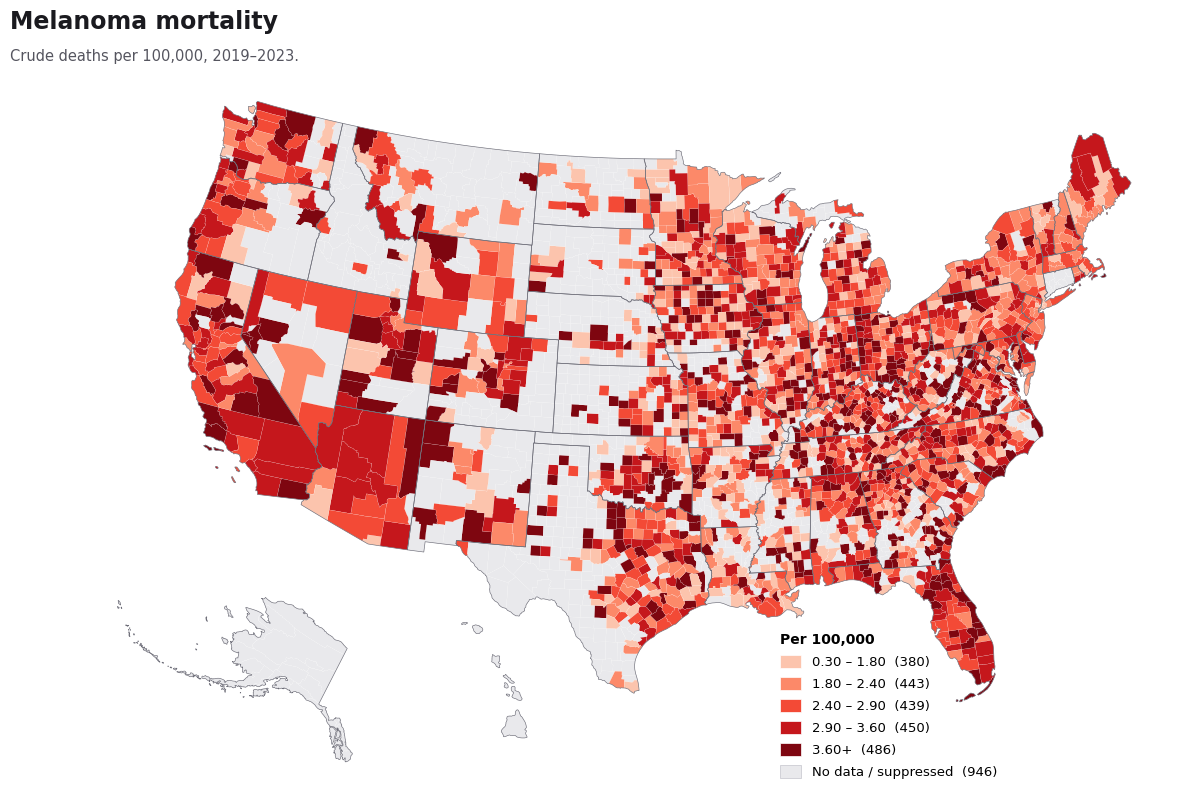

  saved -> outputs/map_06_mir.png


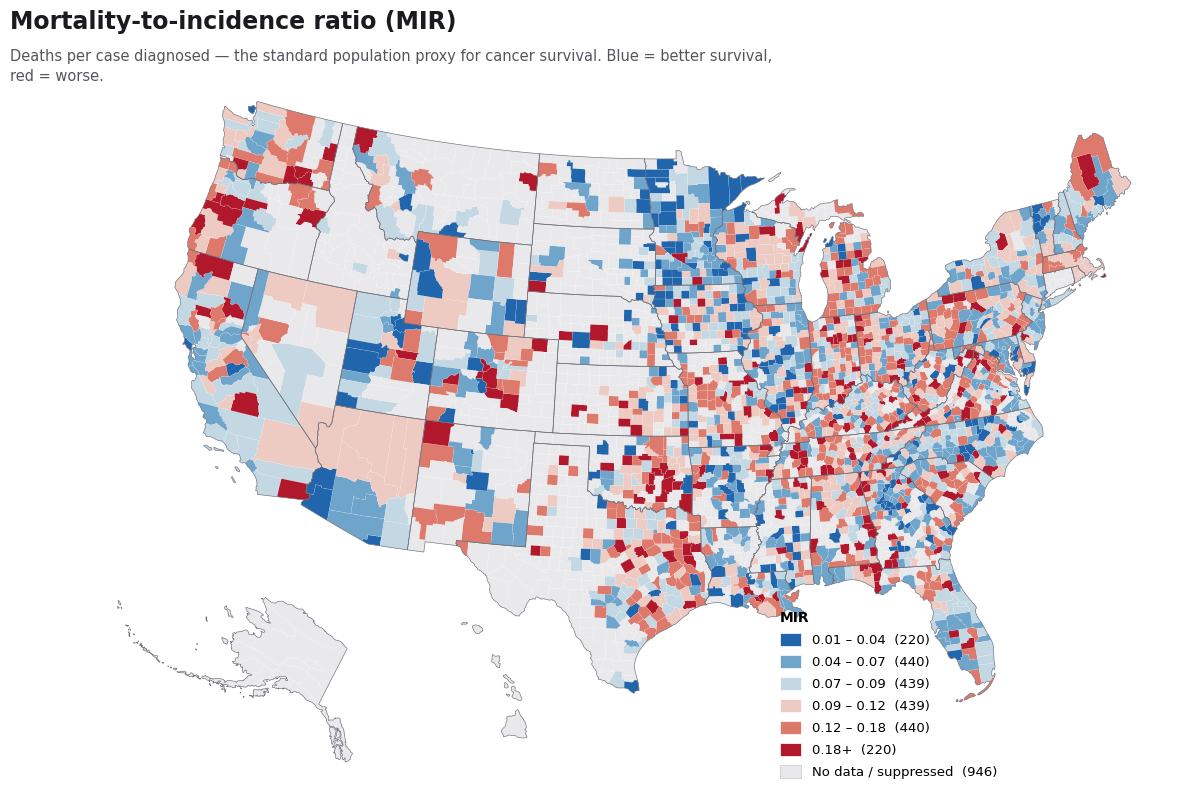

  saved -> outputs/map_07_rurality.png


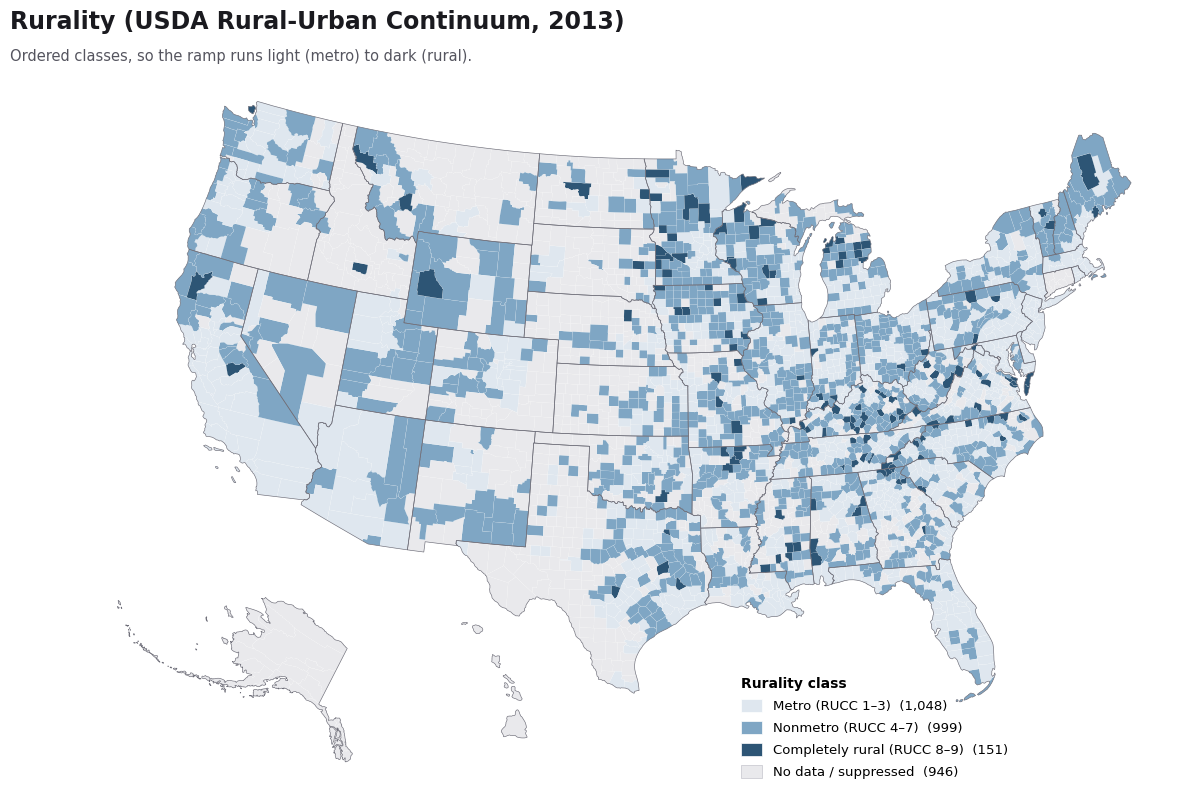

In [12]:
univariate_map(CONFIG["inc_rate"], "Melanoma incidence",
               "Age-adjusted cases per 100,000, 2019–2023. Grey counties were "
               "suppressed and dropped before analysis.",
               "Per 100,000", "YlOrBr", "None", "map_04_incidence.png")

univariate_map(CONFIG["mort_rate"], "Melanoma mortality",
               "Crude deaths per 100,000, 2019–2023.",
               "Per 100,000", "Reds", "None", "map_05_mortality.png")

univariate_map("mir", "Mortality-to-incidence ratio (MIR)",
               "Deaths per case diagnosed — the standard population proxy for "
               "cancer survival. Blue = better survival, red = worse.",
               "MIR", MIR_CMAP, "", "map_06_mir.png", diverging=True)

categorical_map(CONFIG["rural_cat"], RURAL_LABELS, RURAL_COLORS,
                "Rurality (USDA Rural-Urban Continuum, 2013)",
                "Ordered classes, so the ramp runs light (metro) to dark (rural).",
                "Rurality class", "map_07_rurality.png")

## Step 12 · Bivariate maps

Each county is coloured by its cell in a 3×3 grid crossing tertiles of two measures.
The legend *is* the colour grid. Three pairings are drawn, and they tell different
stories:

- **access × mortality** — the original disparity question
- **access × incidence** — the *detection* channel (does access find more disease?)
- **incidence × mortality** — the spatial structure of MIR

  saved -> outputs/map_08_biv_access_x_mortality.png


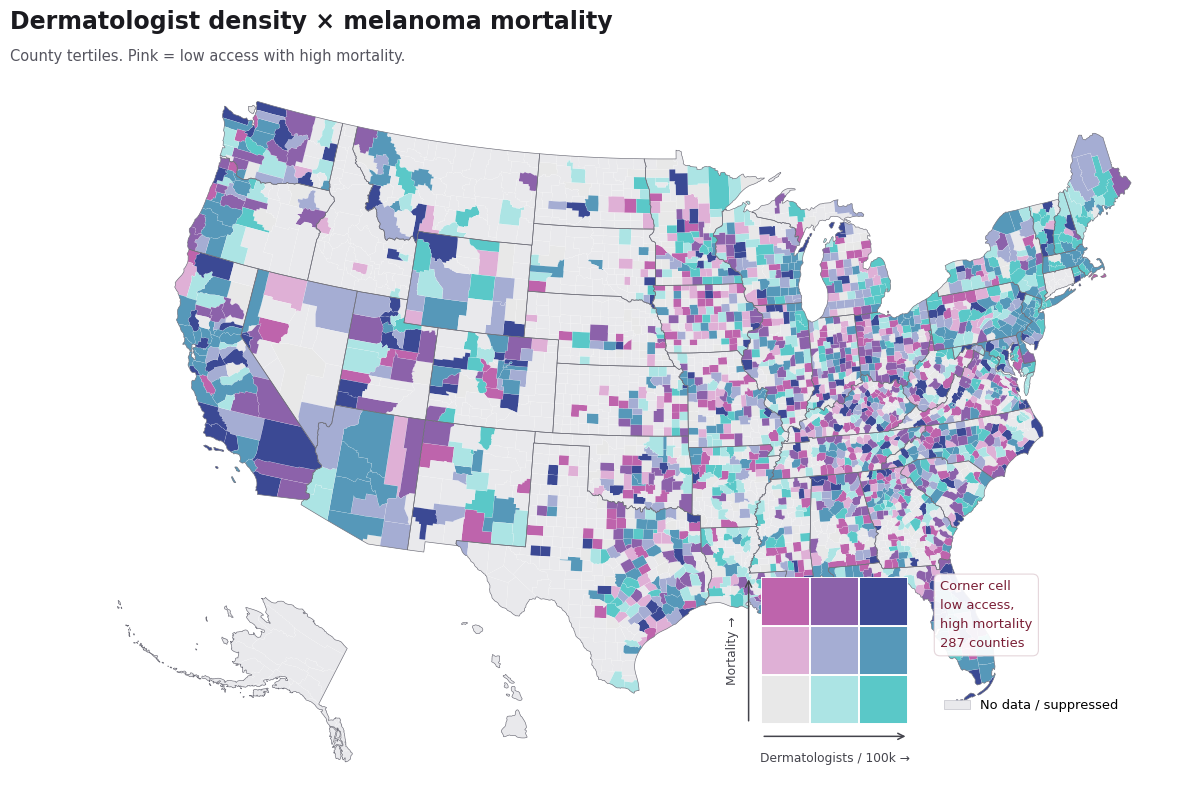

  saved -> outputs/map_09_biv_anyderm_x_mortality.png


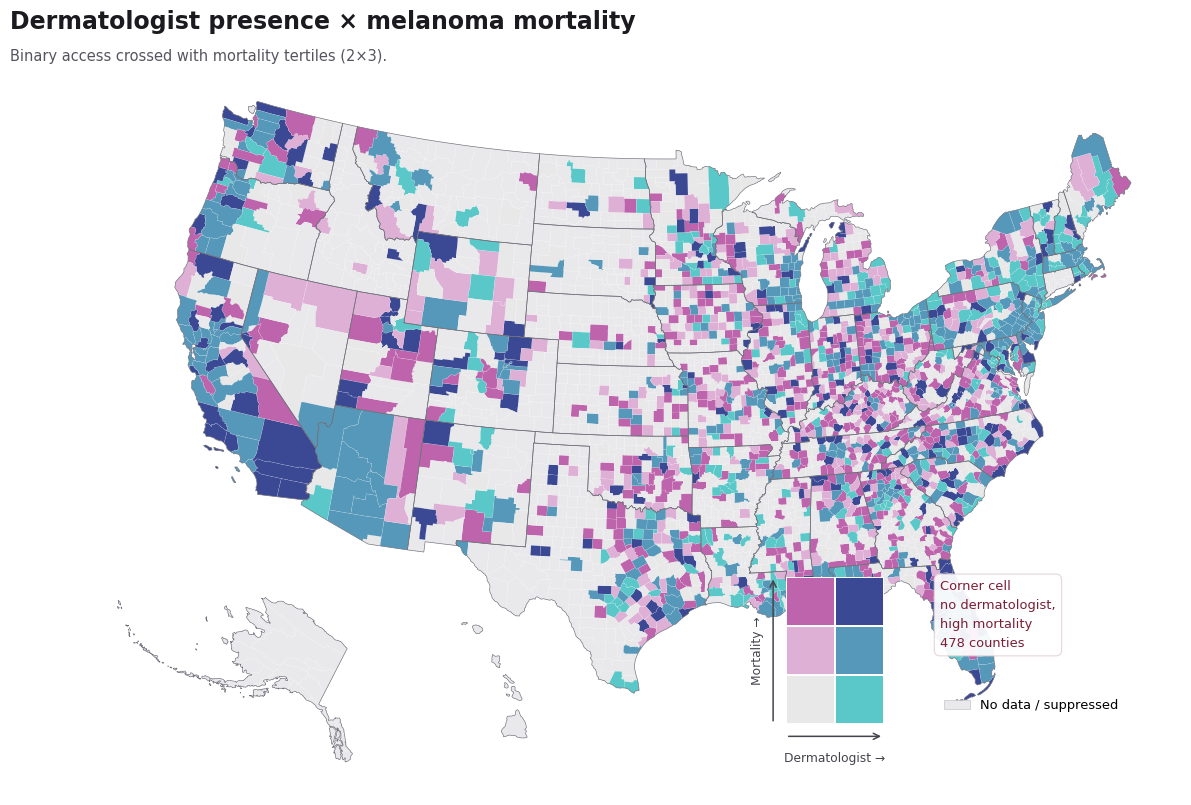

  saved -> outputs/map_10_biv_access_x_incidence.png


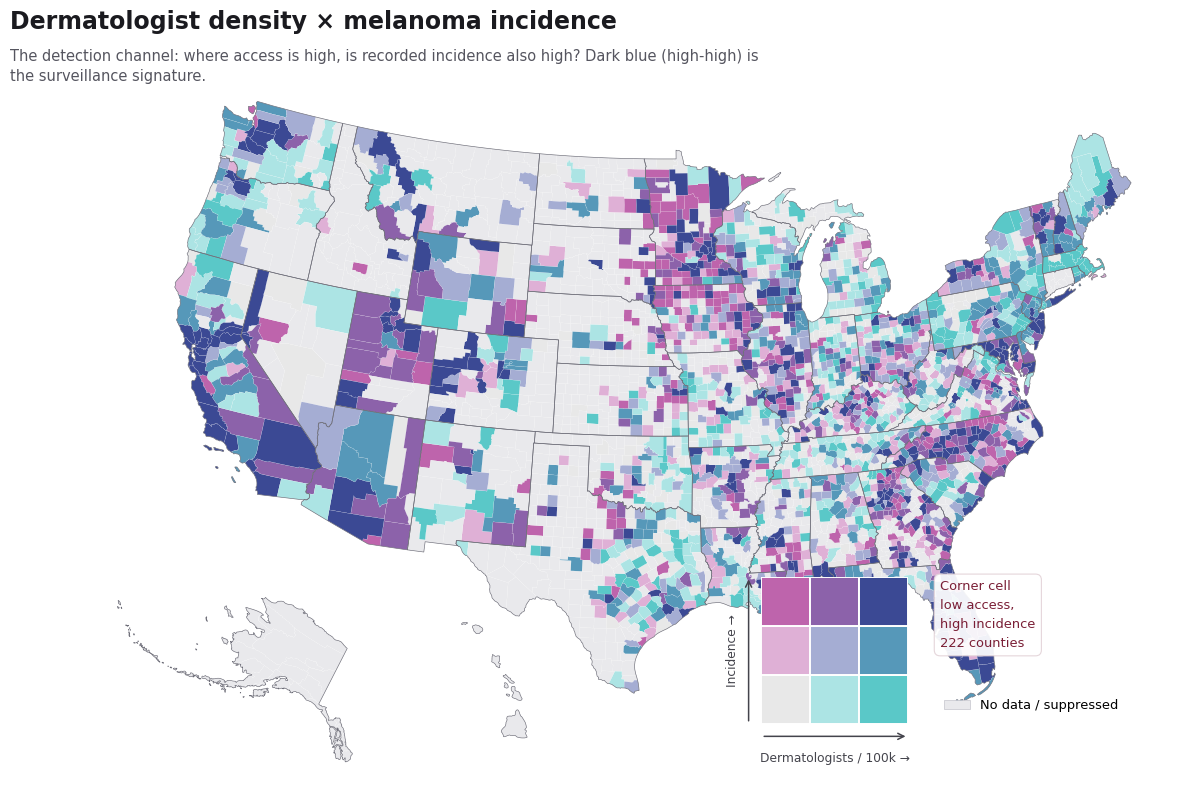

  saved -> outputs/map_11_biv_incidence_x_mortality.png


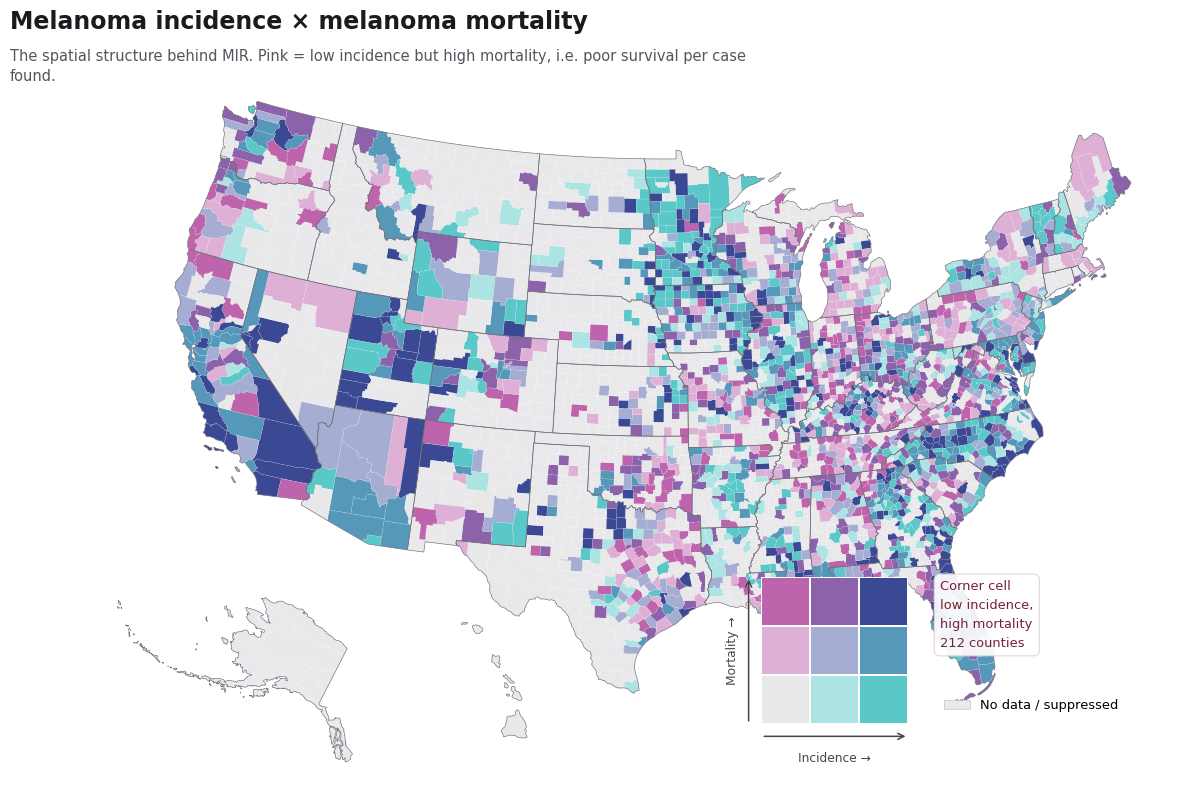

212

In [13]:
def tertiles(s, n=3):
    v = pd.to_numeric(pd.Series(s).reset_index(drop=True), errors="coerce")
    try:
        c = pd.qcut(v, n, labels=False, duplicates="drop")
        if c.nunique(dropna=True) != n:
            raise ValueError
    except Exception:
        c = pd.qcut(v.rank(method="first"), n, labels=False)
    return c

def bivariate_map(xcol, ycol, title, subtitle, xlab, ylab, fname,
                  x_binary=False, pri_note="Lowest x,\nhighest y"):
    d = gdf.reset_index(drop=True)
    yc = tertiles(d[ycol])
    if x_binary:
        xv = pd.to_numeric(d[xcol], errors="coerce")
        xc = xv.where(xv.isna(), (xv > 0).astype(float))
        ncol = 2; grid = [[BIV3[r][0], BIV3[r][2]] for r in range(3)]
    else:
        xc = tertiles(d[xcol]); ncol, grid = 3, BIV3
    face = [NODATA_FACE if (pd.isna(a) or pd.isna(b)) else grid[int(b)][int(a)]
            for a, b in zip(xc, yc)]

    fig, ax = _frame(title, subtitle)
    d.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(d, ax)

    lx = fig.add_axes([0.600, 0.105, 0.112, 0.175])
    for r in range(3):
        for c in range(ncol):
            lx.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=grid[r][c],
                                       edgecolor="white", linewidth=1.4))
    lx.set_xlim(0, ncol); lx.set_ylim(0, 3); lx.set_aspect("equal")
    lx.set_xticks([]); lx.set_yticks([])
    for sp in lx.spines.values(): sp.set_visible(False)
    lx.annotate("", xy=(ncol, -0.26), xytext=(0, -0.26), annotation_clip=False,
                arrowprops=dict(arrowstyle="->", lw=1.1, color="#44444c"))
    lx.annotate("", xy=(-0.26, 3), xytext=(-0.26, 0), annotation_clip=False,
                arrowprops=dict(arrowstyle="->", lw=1.1, color="#44444c"))
    lx.text(ncol/2, -0.58, xlab, ha="center", va="top", fontsize=8.8,
            color="#44444c", clip_on=False)
    lx.text(-0.58, 1.5, ylab, ha="center", va="center", rotation=90, fontsize=8.8,
            color="#44444c", clip_on=False)

    n_pri = int(((xc == 0) & (yc == 2)).sum())
    fig.text(0.734, 0.276, f"Corner cell\n{pri_note}\n{n_pri:,} counties",
             fontsize=9.4, color="#7a1f36", va="top", ha="left", linespacing=1.6,
             bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                       edgecolor="#e3d3d8", linewidth=.8, alpha=.93))
    if pd.isna(xc).any() or pd.isna(yc).any():
        fig.legend(handles=[Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                                  label="No data / suppressed")],
                   loc="lower left", bbox_to_anchor=(0.728, 0.105),
                   bbox_transform=fig.transFigure, frameon=False, fontsize=9.4)
    _finish(fig, ax, fname)
    return n_pri

bivariate_map(CONFIG["derm_rate"], CONFIG["mort_rate"],
              "Dermatologist density × melanoma mortality",
              "County tertiles. Pink = low access with high mortality.",
              "Dermatologists / 100k →", "Mortality →",
              "map_08_biv_access_x_mortality.png",
              pri_note="low access,\nhigh mortality")

bivariate_map(CONFIG["any_derm"], CONFIG["mort_rate"],
              "Dermatologist presence × melanoma mortality",
              "Binary access crossed with mortality tertiles (2×3).",
              "Dermatologist →", "Mortality →",
              "map_09_biv_anyderm_x_mortality.png", x_binary=True,
              pri_note="no dermatologist,\nhigh mortality")

bivariate_map(CONFIG["derm_rate"], CONFIG["inc_rate"],
              "Dermatologist density × melanoma incidence",
              "The detection channel: where access is high, is recorded incidence "
              "also high? Dark blue (high-high) is the surveillance signature.",
              "Dermatologists / 100k →", "Incidence →",
              "map_10_biv_access_x_incidence.png",
              pri_note="low access,\nhigh incidence")

bivariate_map(CONFIG["inc_rate"], CONFIG["mort_rate"],
              "Melanoma incidence × melanoma mortality",
              "The spatial structure behind MIR. Pink = low incidence but high "
              "mortality, i.e. poor survival per case found.",
              "Incidence →", "Mortality →",
              "map_11_biv_incidence_x_mortality.png",
              pri_note="low incidence,\nhigh mortality")

## Step 13 · Mortality against incidence, grouped by dermatologist access

The graph you asked for. Read it as follows: the **slope** is how mortality scales
with disease burden; the **vertical gap between the two lines at a fixed incidence**
is the access association holding burden constant — the same quantity the
incidence-adjusted regression in Step 19 estimates.

The right-hand panel bins counties into incidence deciles because 2,000-plus
overlapping points hide the very gap the chart exists to show.

  saved -> outputs/fig_01_mortality_vs_incidence.png


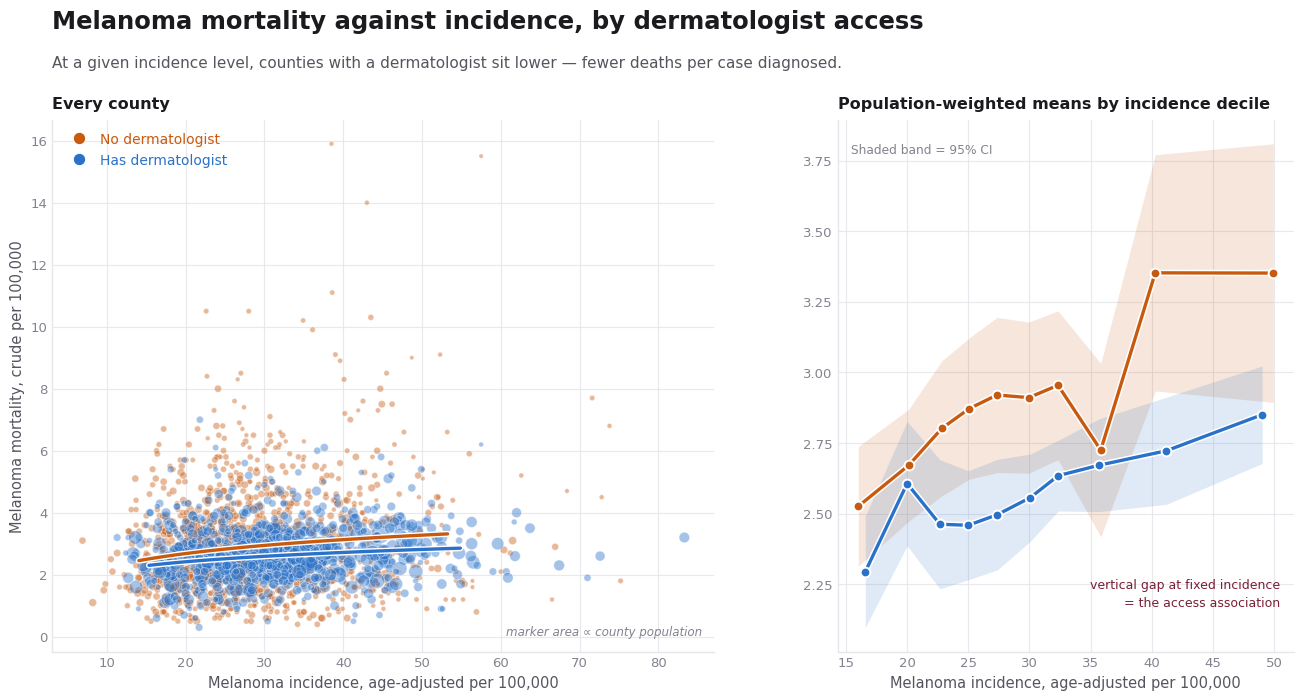

In [14]:
import statsmodels.api as sm

def _style(ax):
    ax.set_facecolor("white")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(GRID); ax.spines[s].set_linewidth(1)
    ax.grid(True, color=GRID, lw=.8, alpha=.85); ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, length=0, labelsize=9.5)

IR, MR, AD, WT = CONFIG["inc_rate"], CONFIG["mort_rate"], CONFIG["any_derm"], CONFIG["weight"]

def scatter_with_fits(ax, sub, size_ref=None, legend=True):
    ref = size_ref if size_ref is not None else sub
    for g in (0, 1):
        s = sub[sub[AD] == g]
        if not len(s): continue
        sz = np.clip(np.sqrt(s[WT])/np.sqrt(ref[WT]).max()*230, 9, 260)
        ax.scatter(s[IR], s[MR], s=sz, c=GRP[g][1], alpha=.42,
                   linewidths=.6, edgecolors="white", zorder=3)
    for g in (0, 1):
        s = sub[sub[AD] == g]
        if len(s) < 25: continue
        fit = sm.WLS(s[MR], sm.add_constant(np.log(s[IR])), weights=s[WT]).fit()
        xs = np.linspace(s[IR].quantile(.02), s[IR].quantile(.98), 120)
        ys = fit.params.iloc[0] + fit.params.iloc[1]*np.log(xs)
        ax.plot(xs, ys, color="white", lw=4.4, zorder=5, solid_capstyle="round")
        ax.plot(xs, ys, color=GRP[g][1], lw=2.4, zorder=6, solid_capstyle="round")
    _style(ax)
    if legend:
        h = [Line2D([], [], marker="o", ls="", ms=9, mfc=GRP[g][1], mec="white",
                    mew=.8, label=GRP[g][0]) for g in (0, 1)]
        lg = ax.legend(handles=h, loc="upper left", frameon=False, fontsize=10,
                       handletextpad=.5)
        for t_, g in zip(lg.get_texts(), (0, 1)): t_.set_color(GRP[g][1])

fig = plt.figure(figsize=(13.6, 7.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=.22,
                      left=.062, right=.975, top=.80, bottom=.10)

axA = fig.add_subplot(gs[0, 0])
scatter_with_fits(axA, df)
axA.set_xlabel("Melanoma incidence, age-adjusted per 100,000", fontsize=10.5, color=INK2)
axA.set_ylabel("Melanoma mortality, crude per 100,000", fontsize=10.5, color=INK2)
axA.set_title("Every county", fontsize=11.5, color=INK, loc="left", pad=8, fontweight="bold")
axA.text(.982, .03, "marker area ∝ county population", transform=axA.transAxes,
         ha="right", fontsize=8.6, color=MUTED, style="italic")

axB = fig.add_subplot(gs[0, 1])
tmp = df.copy(); tmp["_bin"] = pd.qcut(tmp[IR], 10, labels=False)
for g in (0, 1):
    s = tmp[tmp[AD] == g]
    gb = s.groupby("_bin").apply(lambda t: pd.Series({
        "x": np.average(t[IR], weights=t[WT]),
        "y": np.average(t[MR], weights=t[WT]),
        "se": t[MR].std()/max(np.sqrt(len(t)), 1), "n": len(t)}))
    gb = gb[gb.n >= 8]
    axB.fill_between(gb.x, gb.y-1.96*gb.se, gb.y+1.96*gb.se, color=GRP[g][1],
                     alpha=.15, lw=0, zorder=2)
    axB.plot(gb.x, gb.y, color="white", lw=4.6, zorder=3, solid_capstyle="round")
    axB.plot(gb.x, gb.y, color=GRP[g][1], lw=2.4, marker="o", ms=7, mec="white",
             mew=1.4, zorder=4, solid_capstyle="round")
_style(axB)
axB.set_xlabel("Melanoma incidence, age-adjusted per 100,000", fontsize=10.5, color=INK2)
axB.set_title("Population-weighted means by incidence decile", fontsize=11.5,
              color=INK, loc="left", pad=8, fontweight="bold")
axB.text(.03, .955, "Shaded band = 95% CI", transform=axB.transAxes, fontsize=8.8,
         color=MUTED, va="top")
axB.text(.97, .08, "vertical gap at fixed incidence\n= the access association",
         transform=axB.transAxes, ha="right", fontsize=9, color="#7a1f36",
         va="bottom", linespacing=1.5)

fig.text(.062, .945, "Melanoma mortality against incidence, by dermatologist access",
         fontsize=17.5, fontweight="bold", ha="left", va="top", color=INK)
fig.text(.062, .885, "At a given incidence level, counties with a dermatologist sit "
                     "lower — fewer deaths per case diagnosed.",
         fontsize=11, color=INK2, ha="left", va="top")
p = os.path.join(CONFIG["out_dir"], "fig_01_mortality_vs_incidence.png")
fig.savefig(p, dpi=CONFIG["dpi"], facecolor="white"); print("  saved ->", p); plt.show()

### The same relationship, split by rurality

  saved -> outputs/fig_02_mortality_vs_incidence_by_rurality.png


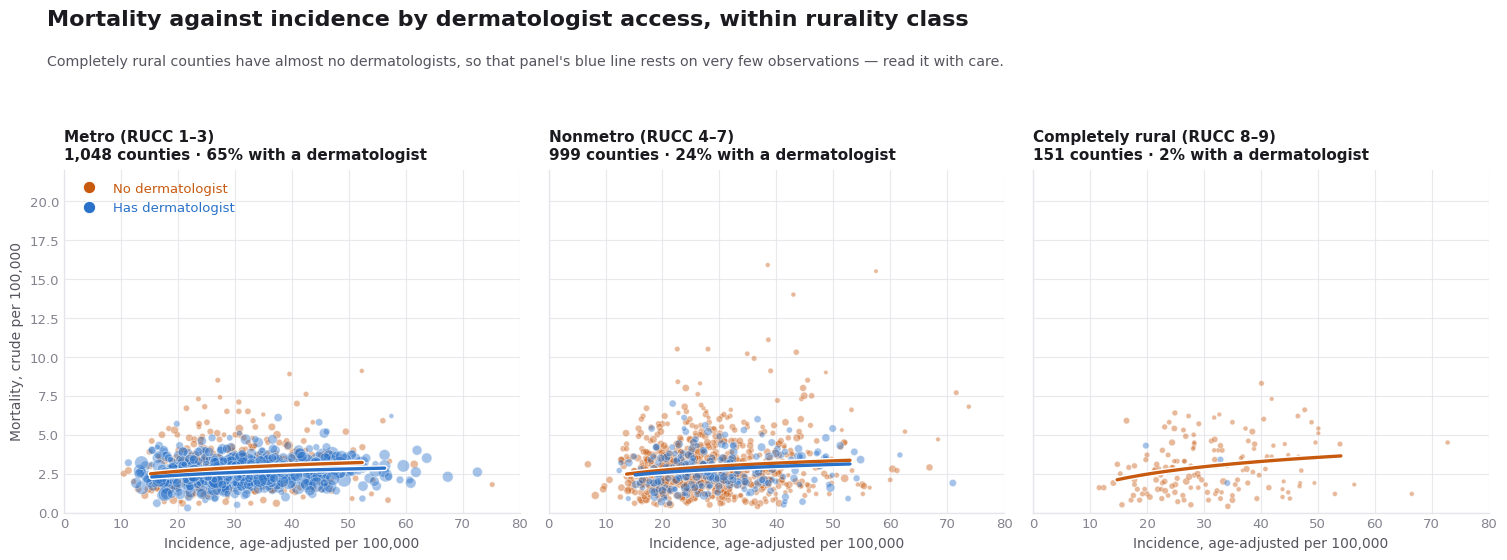

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15.2, 5.6), sharex=True, sharey=True)
for ax, rc in zip(axes, [1, 2, 3]):
    sub = df[df[CONFIG["rural_cat"]] == rc]
    scatter_with_fits(ax, sub, size_ref=df, legend=False)
    n1 = int((sub[AD] == 1).sum())
    ax.set_title(f"{RURAL_LABELS[rc]}\n{len(sub):,} counties · "
                 f"{n1/max(len(sub),1)*100:.0f}% with a dermatologist",
                 fontsize=11, color=INK, loc="left", pad=8, fontweight="bold")
    ax.set_xlabel("Incidence, age-adjusted per 100,000", fontsize=10, color=INK2)
axes[0].set_ylabel("Mortality, crude per 100,000", fontsize=10, color=INK2)
axes[0].set_xlim(0, 80); axes[0].set_ylim(0, 22)
h = [Line2D([], [], marker="o", ls="", ms=9, mfc=GRP[g][1], mec="white", mew=.8,
            label=GRP[g][0]) for g in (0, 1)]
lg = axes[0].legend(handles=h, loc="upper left", frameon=False, fontsize=9.5)
for t_, g in zip(lg.get_texts(), (0, 1)): t_.set_color(GRP[g][1])
fig.suptitle("Mortality against incidence by dermatologist access, within rurality class",
             fontsize=16, fontweight="bold", x=.035, ha="left", y=.995, color=INK)
fig.text(.035, .915, "Completely rural counties have almost no dermatologists, so that "
                     "panel's blue line rests on very few observations — read it with care.",
         fontsize=10.3, color=INK2, ha="left", va="top")
plt.tight_layout(rect=[0, 0, 1, .875])
p = os.path.join(CONFIG["out_dir"], "fig_02_mortality_vs_incidence_by_rurality.png")
fig.savefig(p, dpi=CONFIG["dpi"], facecolor="white"); print("  saved ->", p); plt.show()

### MIR by rurality and access — the survival gap in one view

  saved -> outputs/fig_03_mir_by_rurality_access.png


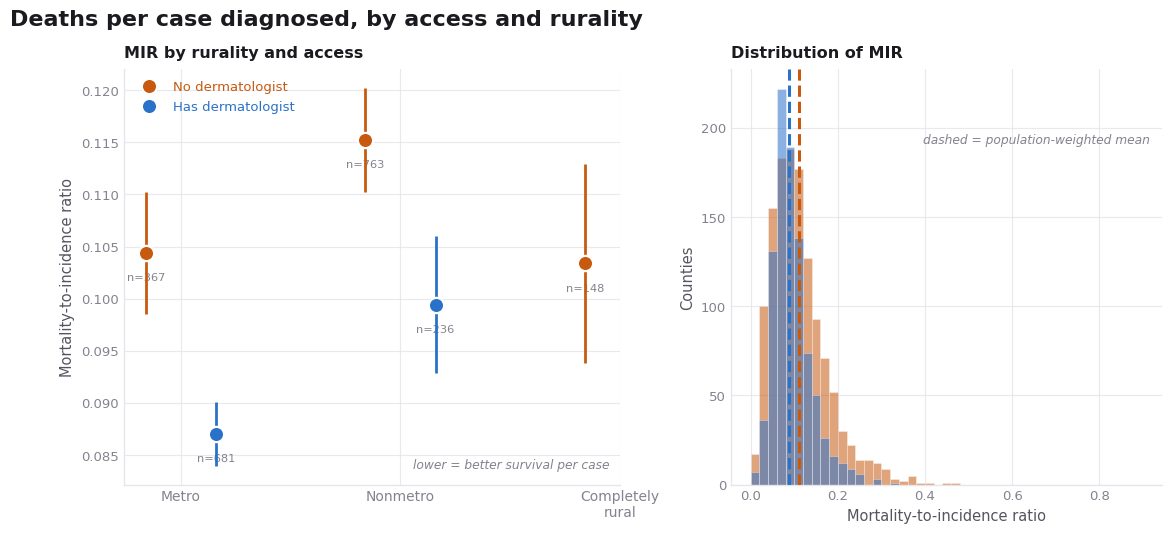

,rc,g,mir,se,n
0,1,0,0.1044,0.0030,367
1,1,1,0.0870,0.0016,681
2,2,0,0.1153,0.0025,763
3,2,1,0.0994,0.0034,236
4,3,0,0.1034,0.0049,148


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 5.4),
                               gridspec_kw={"width_ratios": [1.15, 1], "wspace": .24})

cells = []
for rc in [1, 2, 3]:
    for g in (0, 1):
        s = df[(df[CONFIG["rural_cat"]] == rc) & (df[AD] == g)]
        if len(s) < 5: continue
        m = np.average(s["mir"], weights=s[WT])
        se = s["mir"].std()/np.sqrt(len(s))
        cells.append({"rc": rc, "g": g, "mir": m, "se": se, "n": len(s)})
cd = pd.DataFrame(cells)

for g in (0, 1):
    s = cd[cd.g == g]
    off = -0.16 if g == 0 else 0.16
    ax1.errorbar(s.rc + off, s.mir, yerr=1.96*s.se, fmt="o", ms=11, color=GRP[g][1],
                 mec="white", mew=1.6, elinewidth=2, capsize=0, label=GRP[g][0], zorder=4)
    for _, r in s.iterrows():
        ax1.annotate(f"n={int(r.n):,}", (r.rc+off, r.mir), textcoords="offset points",
                     xytext=(0, -20), ha="center", fontsize=8.2, color=MUTED)
_style(ax1)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(["Metro", "Nonmetro", "Completely\nrural"], fontsize=10)
ax1.set_ylabel("Mortality-to-incidence ratio", fontsize=10.5, color=INK2)
ax1.set_title("MIR by rurality and access", fontsize=11.5, color=INK, loc="left",
              pad=8, fontweight="bold")
lg = ax1.legend(frameon=False, fontsize=9.5, loc="upper left")
for t_, g in zip(lg.get_texts(), (0, 1)): t_.set_color(GRP[g][1])
ax1.text(.98, .04, "lower = better survival per case", transform=ax1.transAxes,
         ha="right", fontsize=8.8, color=MUTED, style="italic")

for g in (0, 1):
    s = df[df[AD] == g]["mir"].dropna()
    ax2.hist(s, bins=45, range=(0, 0.9), alpha=.55, color=GRP[g][1],
             label=GRP[g][0], edgecolor="white", linewidth=.4)
    ax2.axvline(np.average(df[df[AD] == g]["mir"], weights=df[df[AD] == g][WT]),
                color=GRP[g][1], lw=2.2, ls="--", zorder=5)
_style(ax2)
ax2.set_xlabel("Mortality-to-incidence ratio", fontsize=10.5, color=INK2)
ax2.set_ylabel("Counties", fontsize=10.5, color=INK2)
ax2.set_title("Distribution of MIR", fontsize=11.5, color=INK, loc="left",
              pad=8, fontweight="bold")
ax2.text(.97, .82, "dashed = population-weighted mean", transform=ax2.transAxes,
         ha="right", fontsize=8.8, color=MUTED, style="italic")

fig.suptitle("Deaths per case diagnosed, by access and rurality", fontsize=16,
             fontweight="bold", x=.04, ha="left", y=.99, color=INK)
plt.tight_layout(rect=[0, 0, 1, .93])
p = os.path.join(CONFIG["out_dir"], "fig_03_mir_by_rurality_access.png")
fig.savefig(p, dpi=CONFIG["dpi"], facecolor="white"); print("  saved ->", p); plt.show()
display(cd.round(4))

## Step 14 · Spatial weights

**Queen contiguity** from the actual polygons — two counties are neighbours if they
share any boundary point. Correct for areal data; k-nearest-neighbours on centroids
would link counties across water and state lines.

One consequence of the suppression deserves emphasis: because ~29% of counties were
dropped, **the analysis surface has holes in it**. Two counties that are neighbours in
reality may be non-adjacent here because the county between them is missing. Average
neighbour counts will run below the ~5.9 typical of a complete US county lattice, and
every spatial statistic below is conditional on that punctured surface.

In [17]:
from libpysal.weights import Queen, KNN, attach_islands
from libpysal.weights import W as PysalW

analysis = (g_base.merge(df, on="FIPS", how="inner")
                  .to_crs(CRS_ALBERS).reset_index(drop=True))
analysis = analysis[analysis[CONFIG["mort_rate"]].notna()].reset_index(drop=True)
print(f"Analysis set: {len(analysis):,} counties\n")

w = Queen.from_dataframe(analysis, use_index=False, silence_warnings=True)
if len(w.islands):
    print(f"  {len(w.islands)} island counties -> attached to nearest neighbour")
    w = attach_islands(w, KNN.from_dataframe(analysis, k=1, silence_warnings=True),
                       silence_warnings=True)
w.transform = "r"
card = np.array(list(w.cardinalities.values()))
print(f"  Queen W: n={w.n:,}, mean neighbours={card.mean():.2f}, "
      f"range {card.min()}–{card.max()}")
print(f"  (a complete US county lattice averages ~5.9; the shortfall is the "
      f"suppression holes)")

def pop_scaled_weights(w_base, pop):
    # row-standardised W where each neighbour's weight is proportional to its population
    pop = np.asarray(pop, float)
    ids = list(w_base.id_order); pos = {k: i for i, k in enumerate(ids)}
    nb, wt = {}, {}
    for k in ids:
        nk = list(w_base.neighbors[k]); nb[k] = nk
        if not nk:
            wt[k] = []; continue
        raw = np.array([pop[pos[j]] for j in nk], float)
        wt[k] = list(raw/raw.sum()) if raw.sum() > 0 else [1/len(nk)]*len(nk)
    return PysalW(nb, wt, id_order=ids, silence_warnings=True)

w_pop = pop_scaled_weights(w, analysis[CONFIG["weight"]].values)
print(f"  Population-scaled W built (neighbour influence ∝ {CONFIG['weight']})")

Analysis set: 2,198 counties

  20 island counties -> attached to nearest neighbour
  Queen W: n=2,198, mean neighbours=4.88, range 1–10
  (a complete US county lattice averages ~5.9; the shortfall is the suppression holes)
  Population-scaled W built (neighbour influence ∝ pop)


## Step 15 · Global Moran's I

Empirical-Bayes variants (`Moran_Rate`) shrink rates from small-denominator counties
toward the global mean, which is how the population weight enters a *rate* outcome
correctly. Compare each raw row with its EB row: a large drop means the raw figure was
inflated by unstable small-county rates.

In [18]:
from esda.moran import Moran, Moran_Rate, Moran_BV

P = CONFIG["permutations"]
np.random.seed(CONFIG["random_seed"])
IR, MR, AD, WT = CONFIG["inc_rate"], CONFIG["mort_rate"], CONFIG["any_derm"], CONFIG["weight"]

mort_e = analysis[CONFIG["mort_event"]].values; mort_b = analysis[CONFIG["mort_denom"]].values
inc_e  = analysis[CONFIG["inc_event"]].values;  inc_b  = analysis[CONFIG["inc_denom"]].values
derm_e = analysis[CONFIG["derm_count"]].values; derm_b = analysis[CONFIG["derm_denom"]].values

specs = {
    "Mortality, raw rate":            Moran(analysis[MR].values, w, permutations=P),
    "Mortality, EB (pop-weighted)":   Moran_Rate(mort_e, mort_b, w, permutations=P),
    "Mortality, pop-scaled W":        Moran(analysis[MR].values, w_pop, permutations=P),
    "Incidence, raw rate":            Moran(analysis[IR].values, w, permutations=P),
    "Incidence, EB (pop-weighted)":   Moran_Rate(inc_e, inc_b, w, permutations=P),
    "MIR (log)":                      Moran(analysis["log_mir"].values, w, permutations=P),
    "Dermatologist access, EB":       Moran_Rate(derm_e, derm_b, w, permutations=P),
}

def stars(p):
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""

rows = []
for name, m in specs.items():
    rows.append({"Measure": name, "Moran's I": round(float(m.I), 4),
                 "z": round(float(m.z_sim), 2),
                 "p (perm)": f"{m.p_sim:.4f}{stars(m.p_sim)}",
                 "Pattern": ("clustered" if m.p_sim < .05 and m.I > m.EI
                             else "dispersed" if m.p_sim < .05 else "random")})
moran_tbl = pd.DataFrame(rows)
display(moran_tbl)
print(f"{P} permutations.  * p<.05  ** p<.01  *** p<.001")
moran_tbl.to_csv(os.path.join(CONFIG["out_dir"], "global_morans_i.csv"), index=False)

m_bv = Moran_BV(analysis[CONFIG["derm_rate"]].values, analysis[MR].values, w, permutations=P)
print(f"\nBivariate Moran's I (access vs NEIGHBOURS' mortality): "
      f"I={m_bv.I:+.4f}  p={m_bv.p_sim:.4f}")

,Measure,Moran's I,z,p (perm),Pattern
0,"Mortality, raw rate",0.0437,3.04,0.0030**,clustered
1,"Mortality, EB (pop-weighted)",0.1739,11.62,0.0010**,clustered
2,"Mortality, pop-scaled W",0.0503,3.28,0.0020**,clustered
3,"Incidence, raw rate",0.4784,31.94,0.0010**,clustered
4,"Incidence, EB (pop-weighted)",0.4925,35.38,0.0010**,clustered
5,MIR (log),0.1883,13.24,0.0010**,clustered
6,"Dermatologist access, EB",0.1571,11.86,0.0010**,clustered


999 permutations.  * p<.05  ** p<.01  *** p<.001

Bivariate Moran's I (access vs NEIGHBOURS' mortality): I=-0.0397  p=0.0010


## Step 16 · LISA clusters and maps

In [19]:
from esda.moran import Moran_Local, Moran_Local_Rate, Moran_Local_BV

def fdr_bh(p, q=0.05):
    p = np.asarray(p, float); n = p.size
    order = np.argsort(p); passed = p[order] <= q*(np.arange(1, n+1)/n)
    keep = np.zeros(n, bool)
    if passed.any():
        keep[order[:np.max(np.where(passed)[0])+1]] = True
    return keep

np.random.seed(CONFIG["random_seed"])
l_mort = Moran_Local_Rate(mort_e, mort_b, w, permutations=P)
l_inc  = Moran_Local_Rate(inc_e, inc_b, w, permutations=P)
l_derm = Moran_Local_Rate(derm_e, derm_b, w, permutations=P)
l_mir  = Moran_Local(analysis["log_mir"].values, w, permutations=P)
l_bv   = Moran_Local_BV(analysis[CONFIG["derm_rate"]].values, analysis[MR].values,
                        w, permutations=P)

for key, loc in [("mortality", l_mort), ("incidence", l_inc),
                 ("derm", l_derm), ("mir", l_mir), ("bivariate", l_bv)]:
    analysis[f"lisa_{key}"]     = np.where(loc.p_sim < 0.05, loc.q, 0)
    analysis[f"lisa_{key}_fdr"] = np.where(fdr_bh(loc.p_sim), loc.q, 0)

summary = pd.DataFrame({
    k.capitalize(): pd.Series(analysis[f"lisa_{k}"]).map(LISA_LABELS).value_counts()
    for k in ["mortality", "incidence", "derm", "mir"]}).fillna(0).astype(int)
order = [LISA_LABELS[k] for k in (1, 3, 2, 4, 0)]
display(summary.reindex([o for o in order if o in summary.index]))
print("p < 0.05, uncorrected. FDR-corrected columns are in the exported CSV; LISA runs")
print("thousands of simultaneous tests, so treat these as screening, not confirmation.")

,Mortality,Incidence,Derm,Mir
High–High,125,258,100,156
Low–Low,113,360,119,146
Low–High,53,31,56,56
High–Low,46,20,38,62
Not significant,1861,1529,1885,1778


p < 0.05, uncorrected. FDR-corrected columns are in the exported CSV; LISA runs
thousands of simultaneous tests, so treat these as screening, not confirmation.


  saved -> outputs/map_12_lisa_mortality.png


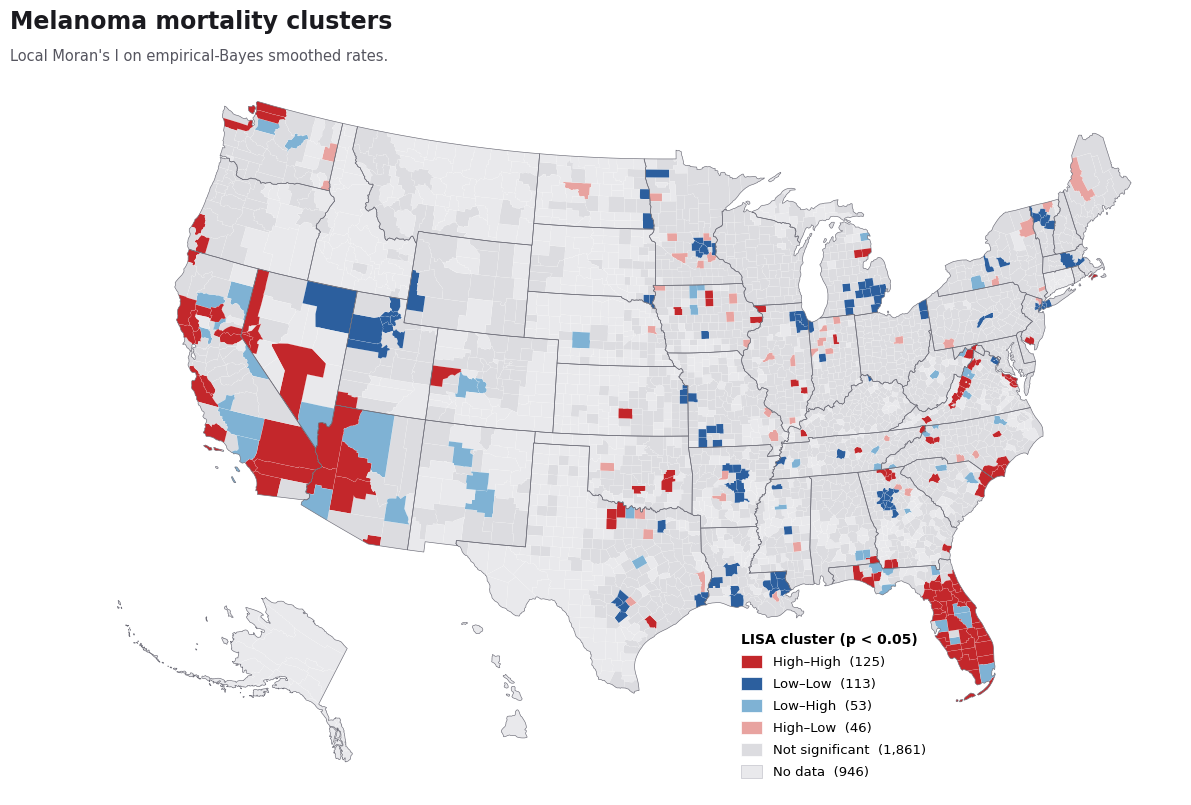

  saved -> outputs/map_13_lisa_incidence.png


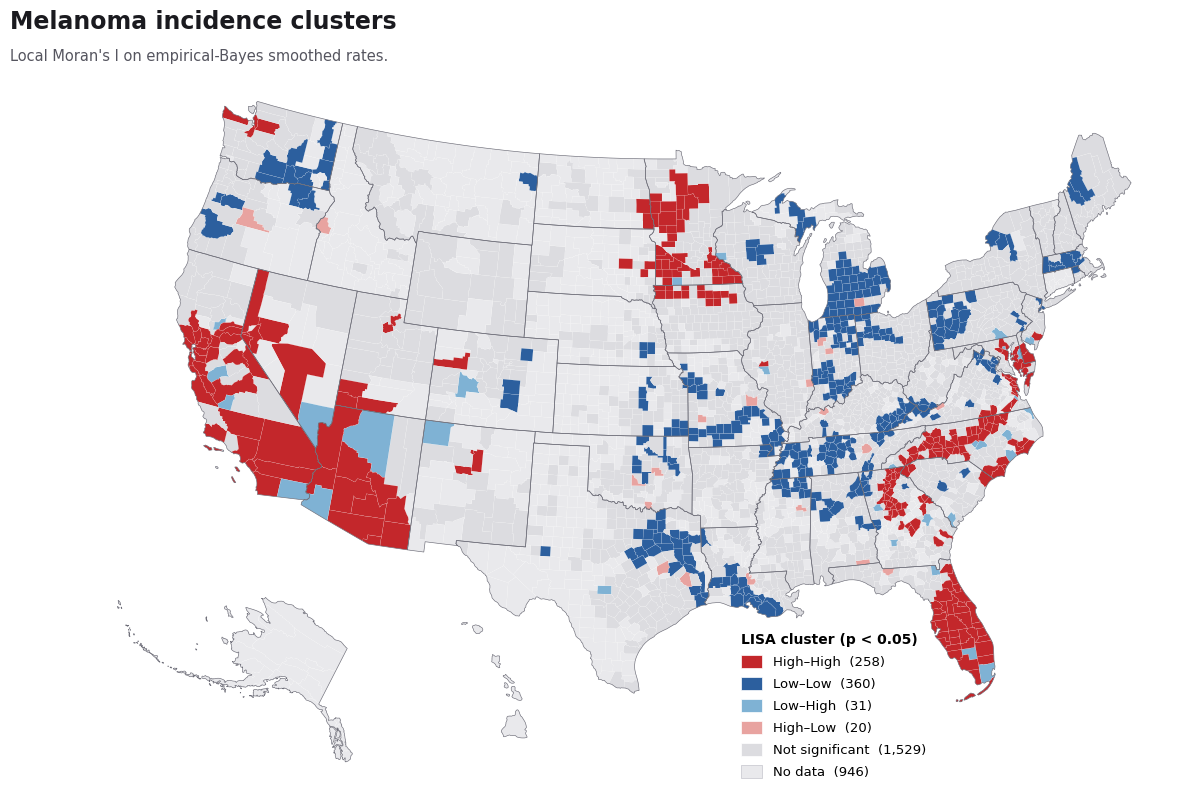

  saved -> outputs/map_14_lisa_mir.png


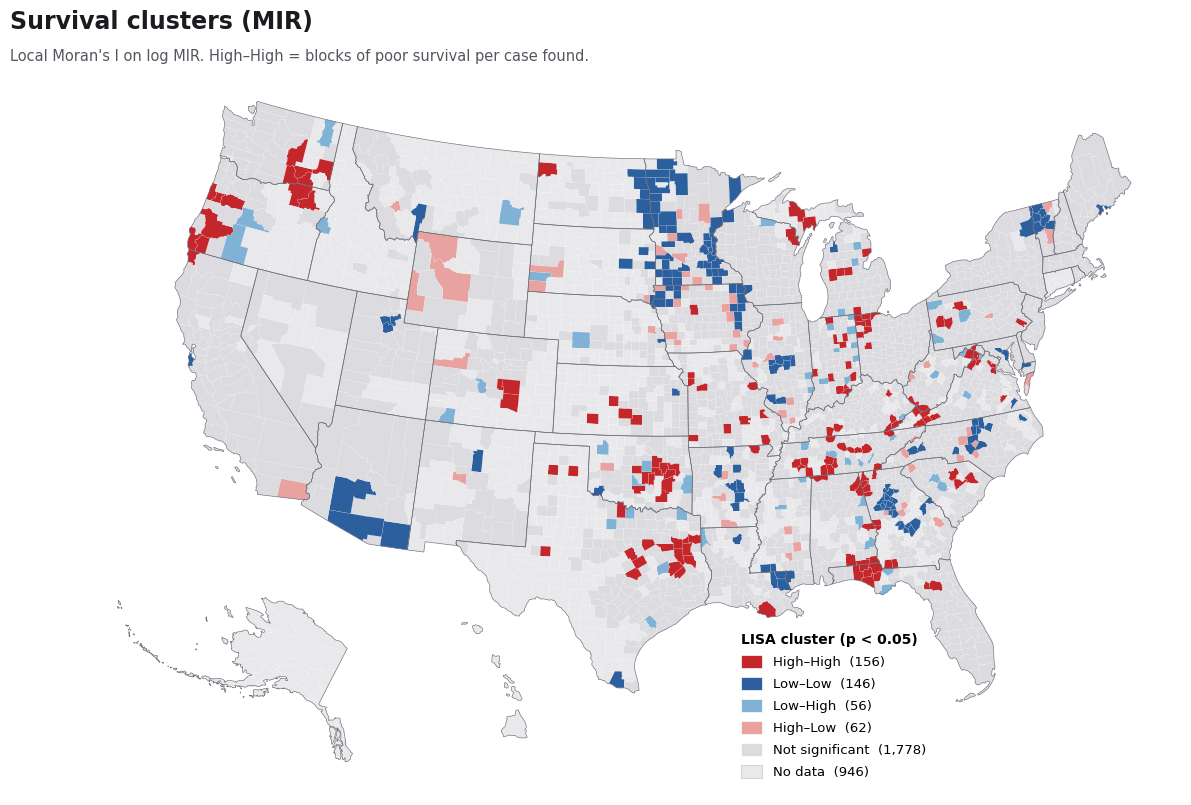

  saved -> outputs/map_15_lisa_bivariate.png


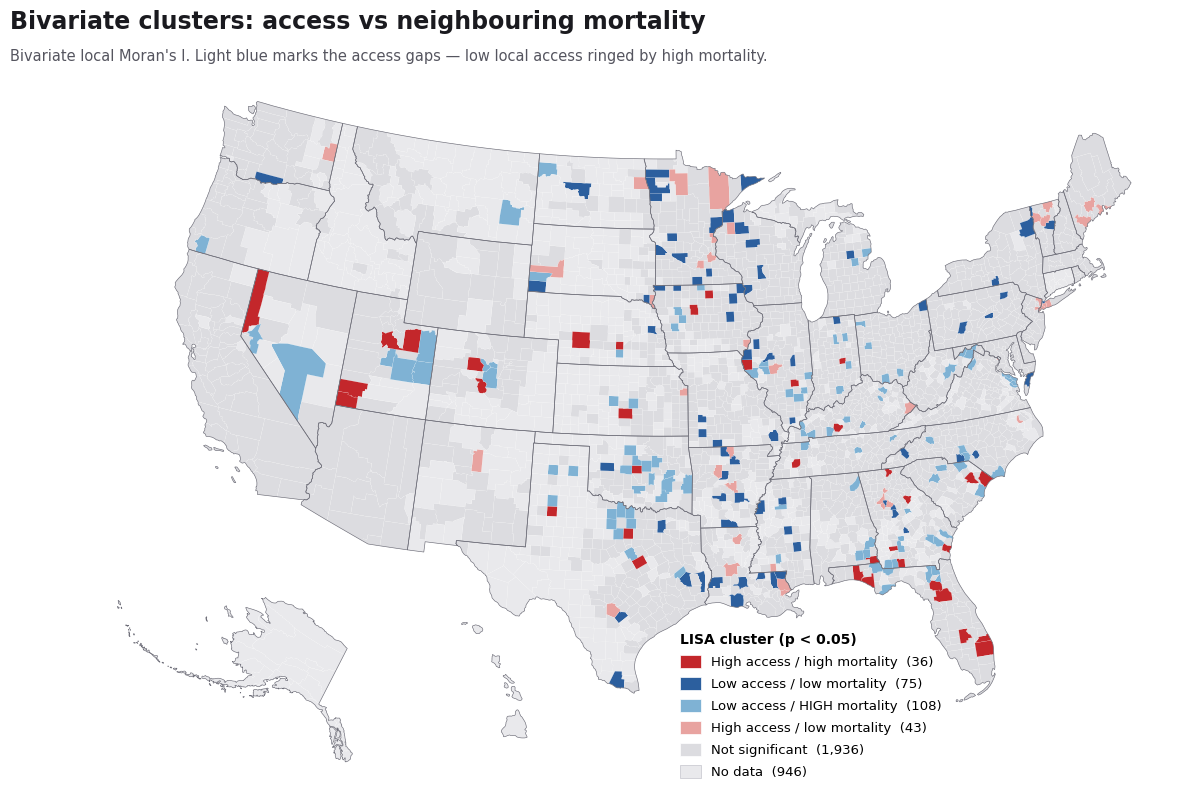


Access-gap clusters: 108 counties


In [20]:
plot_gdf = gdf.merge(analysis[["FIPS"] + [c for c in analysis.columns
                                          if c.startswith("lisa_")]],
                     on="FIPS", how="left")

def lisa_map(qcol, title, subtitle, fname, labels=None, legend_x=0.60):
    labels = labels or LISA_LABELS
    q = plot_gdf[qcol]
    face = [LISA_COLORS[int(x)] if pd.notna(x) else NODATA_FACE for x in q]
    cnt = q.value_counts()
    fig, ax = _frame(title, subtitle)
    plot_gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(plot_gdf, ax)
    h = [Patch(facecolor=LISA_COLORS[k], edgecolor="white", lw=.5,
               label=f"{labels[k]}  ({int(cnt.get(k,0)):,})") for k in (1, 3, 2, 4, 0)]
    if q.isna().any():
        h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                       label=f"No data  ({int(q.isna().sum()):,})"))
    _legend(ax, h, "LISA cluster (p < 0.05)", legend_x)
    _finish(fig, ax, fname)

lisa_map("lisa_mortality", "Melanoma mortality clusters",
         "Local Moran's I on empirical-Bayes smoothed rates.", "map_12_lisa_mortality.png")
lisa_map("lisa_incidence", "Melanoma incidence clusters",
         "Local Moran's I on empirical-Bayes smoothed rates.", "map_13_lisa_incidence.png")
lisa_map("lisa_mir", "Survival clusters (MIR)",
         "Local Moran's I on log MIR. High–High = blocks of poor survival per case found.",
         "map_14_lisa_mir.png")

BV = {0: "Not significant", 1: "High access / high mortality",
      2: "Low access / HIGH mortality", 3: "Low access / low mortality",
      4: "High access / low mortality"}
lisa_map("lisa_bivariate", "Bivariate clusters: access vs neighbouring mortality",
         "Bivariate local Moran's I. Light blue marks the access gaps — low local "
         "access ringed by high mortality.", "map_15_lisa_bivariate.png",
         labels=BV, legend_x=0.545)
print(f"\nAccess-gap clusters: {int((analysis['lisa_bivariate']==2).sum()):,} counties")

## Step 17 · The regression design

Four specifications, each run on the rurality parameterisation you asked for —
`rural_cat` and `metro` **separately**, never together.

| Model | Outcome | Key regressors | Reads as |
|---|---|---|---|
| **A** | incidence | access + rurality | detection channel |
| **B** | mortality | access + rurality | total association |
| **C** | mortality | access + **log incidence** + rurality | case fatality |
| **D** | **log MIR** | access + rurality | case fatality, ratio form |
| **E** | death counts | access + log incidence + rurality, `offset(log pop)` | negative binomial |

Model E exists because B–D regress a *rate* with OLS, which assumes constant variance
— false for rates built on wildly different denominators. A negative binomial on
counts with a population offset is the distributionally honest version, and it should
agree with C and D. If it does not, believe E.

**Reading C against B is the whole point.** If the access coefficient grows more
negative when incidence enters, incidence was *suppressing* the association — access
areas look worse than they are because they find more disease. If it shrinks toward
zero, the unadjusted association was detection artefact.

In [21]:
from spreg import OLS, ML_Lag, ML_Error
import statsmodels.api as sm
import statsmodels.formula.api as smf

a = analysis.copy()
a["log_inc"]  = np.log(a[IR].replace(0, np.nan))
a["log_cinc"] = np.log(a["crude_incidence"].replace(0, np.nan))
a["log_mir"]  = np.log(a["mir"].replace(0, np.nan))
a["rc2"] = (a[CONFIG["rural_cat"]] == 2).astype(float)
a["rc3"] = (a[CONFIG["rural_cat"]] == 3).astype(float)
a["nonmetro"] = (a[CONFIG["metro"]] == 0).astype(float)
a = a[np.isfinite(a.log_inc) & np.isfinite(a.log_mir) & np.isfinite(a.log_cinc)].reset_index(drop=True)

# rebuild W on the estimation sample so rows align exactly
w_est = Queen.from_dataframe(a, use_index=False, silence_warnings=True)
if len(w_est.islands):
    w_est = attach_islands(w_est, KNN.from_dataframe(a, k=1, silence_warnings=True),
                           silence_warnings=True)
w_est.transform = "r"
print(f"Estimation sample: {len(a):,} counties\n")

RURAL_SPECS = {
    "rural_cat": (["anyderm", "rc2", "rc3"],
                  ["anyderm", "nonmetro_RUCC4_7", "completely_rural_RUCC8_9"]),
    "metro":     (["anyderm", "nonmetro"], ["anyderm", "nonmetro"]),
}

def fit_ols(yname, yvec, xcols, xnames):
    X = a[xcols].values.astype(float)
    return OLS(np.asarray(yvec, float).reshape(-1, 1), X, w=w_est,
               spat_diag=True, moran=True, name_y=yname, name_x=xnames)

def tidy(model, names, label):
    out = []
    for i, nm in enumerate(["CONST"] + names):
        out.append({"model": label, "term": nm,
                    "coef": float(model.betas[i][0]),
                    "t": float(model.t_stat[i][0]),
                    "p": float(model.t_stat[i][1])})
    return out

results, diagnostics = [], []
MODELS = [
    ("A. Incidence",              IR,        False),
    ("B. Mortality (unadj)",      MR,        False),
    ("C. Mortality (+incidence)", MR,        True),
    ("D. log MIR",                "log_mir", False),
]

for spec, (xc, xn) in RURAL_SPECS.items():
    for label, ycol, add_inc in MODELS:
        xcols = xc + (["log_inc"] if add_inc else [])
        xnames = xn + (["log_incidence"] if add_inc else [])
        m = fit_ols(ycol, a[ycol].values, xcols, xnames)
        results += [dict(r, spec=spec) for r in tidy(m, xnames, label)]
        diagnostics.append({
            "spec": spec, "model": label, "n": int(m.n), "R2": float(m.r2),
            "resid_MoranI": float(m.moran_res[0]), "resid_Moran_p": float(m.moran_res[2]),
            "LM_lag_p": float(m.lm_lag[1]), "LM_err_p": float(m.lm_error[1]),
            "RLM_lag_p": float(m.rlm_lag[1]), "RLM_err_p": float(m.rlm_error[1]),
        })

res = pd.DataFrame(results); diag = pd.DataFrame(diagnostics)

print("=" * 78)
print("OLS COEFFICIENTS  (rural_cat specification)")
print("=" * 78)
piv = (res[res.spec == "rural_cat"]
       .pivot_table(index="term", columns="model", values="coef"))
pv  = (res[res.spec == "rural_cat"]
       .pivot_table(index="term", columns="model", values="p"))
show = piv.round(4).astype(str) + pv.map(lambda q: stars(q) if pd.notna(q) else "")
display(show)

print("\nSPATIAL DIAGNOSTICS")
display(diag.round(4))

Estimation sample: 2,198 counties

OLS COEFFICIENTS  (rural_cat specification)


model,A. Incidence,B. Mortality (unadj),C. Mortality (+incidence),D. log MIR
term,,,,
CONST,29.7963***,2.9456***,0.9142**,-2.3762***
anyderm,1.8919***,-0.2654***,-0.3038***,-0.0911***
completely_rural_RUCC8_9,1.7038,0.0351,0.0053,-0.1036*
log_incidence,nan,nan,0.6076***,nan
nonmetro_RUCC4_7,-1.5412**,0.0778,0.1121,0.041



SPATIAL DIAGNOSTICS


,spec,model,n,R2,resid_MoranI,resid_Moran_p,LM_lag_p,LM_err_p,RLM_lag_p,RLM_err_p
0,rural_cat,A. Incidence,2198,0.0211,0.4753,0.0000,0.0000,0.0000,0.0037,0.4287
1,rural_cat,B. Mortality (unadj),2198,0.0112,0.0363,0.0113,0.0078,0.0129,0.0315,0.0532
2,rural_cat,C. Mortality (+incidence),2198,0.0307,0.0381,0.0075,0.0175,0.0090,0.1509,0.0721
3,rural_cat,D. log MIR,2198,0.0115,0.1804,0.0000,0.0000,0.0000,0.0004,0.0116
4,metro,A. Incidence,2198,0.0149,0.4802,0.0000,0.0000,0.0000,0.7194,0.0045
5,metro,B. Mortality (unadj),2198,0.0111,0.0367,0.0106,0.0076,0.0120,0.0475,0.0780
6,metro,C. Mortality (+incidence),2198,0.0304,0.0391,0.0061,0.0163,0.0074,0.0845,0.0363
7,metro,D. log MIR,2198,0.0074,0.1857,0.0000,0.0000,0.0000,0.3014,0.8773


### Choosing the spatial model

Anselin's decision rule on the Lagrange Multiplier tests: if both LM-lag and LM-error
are significant, the **robust** versions break the tie. Residual Moran's I above is
significant everywhere, so OLS standard errors are not trustworthy on their own — the
spatial refit below is the inferentially defensible version.

In [22]:
def choose_spatial(row):
    lag, err = row.RLM_lag_p, row.RLM_err_p
    if row.LM_lag_p >= .05 and row.LM_err_p >= .05:  return "OLS"
    if lag < .05 and err >= .05:  return "lag"
    if err < .05 and lag >= .05:  return "error"
    return "lag" if lag < err else "error"

spatial_rows = []
for spec, (xc, xn) in RURAL_SPECS.items():
    for label, ycol, add_inc in MODELS:
        xcols = xc + (["log_inc"] if add_inc else [])
        xnames = xn + (["log_incidence"] if add_inc else [])
        d_row = diag[(diag.spec == spec) & (diag.model == label)].iloc[0]
        pick = choose_spatial(d_row)
        y = a[ycol].values.reshape(-1, 1).astype(float)
        X = a[xcols].values.astype(float)
        try:
            if pick == "lag":
                m = ML_Lag(y, X, w=w_est, name_y=ycol, name_x=xnames)
            elif pick == "error":
                m = ML_Error(y, X, w=w_est, name_y=ycol, name_x=xnames)
            else:
                m = None
        except Exception as e:
            print(f"  {spec}/{label}: spatial fit failed ({e}); keeping OLS")
            m = None
        if m is None:
            continue
        for i, nm in enumerate(["CONST"] + xnames):
            spatial_rows.append({"spec": spec, "model": label, "type": pick, "term": nm,
                                 "coef": float(m.betas[i][0]),
                                 "z": float(m.z_stat[i][0]), "p": float(m.z_stat[i][1])})
        spatial_rows.append({"spec": spec, "model": label, "type": pick,
                             "term": "rho" if pick == "lag" else "lambda",
                             "coef": float(m.betas[-1][0]), "z": np.nan, "p": np.nan})

spatial = pd.DataFrame(spatial_rows)
print("=" * 78)
print("SPATIAL MODEL COEFFICIENTS  (rural_cat specification)")
print("=" * 78)
sp = spatial[spatial.spec == "rural_cat"]
disp = sp.pivot_table(index="term", columns="model", values="coef").round(4).astype(str)
spp = sp.pivot_table(index="term", columns="model", values="p")
display(disp + spp.map(lambda q: stars(q) if pd.notna(q) else ""))
print("\nModel type chosen per outcome:")
display(sp.groupby(["spec", "model"]).type.first().reset_index())

print("\n" + "=" * 78)
print("HEADLINE: what happens to the access coefficient when incidence enters")
print("=" * 78)
for spec in RURAL_SPECS:
    b = res[(res.spec == spec) & (res.model == "B. Mortality (unadj)") & (res.term == "anyderm")]
    c = res[(res.spec == spec) & (res.model == "C. Mortality (+incidence)") & (res.term == "anyderm")]
    if len(b) and len(c):
        bb, cc = b.coef.iloc[0], c.coef.iloc[0]
        print(f"  [{spec}] unadjusted {bb:+.4f} (p={b.p.iloc[0]:.4f})  ->  "
              f"incidence-adjusted {cc:+.4f} (p={c.p.iloc[0]:.4f})")
        print(f"            {'STRENGTHENS - incidence was suppressing it' if abs(cc) > abs(bb) else 'ATTENUATES - part of it was detection artefact'}")

ML_Lag
ML_Lag
ML_Error
ML_Lag
ML_Error
ML_Lag
ML_Error
ML_Lag
SPATIAL MODEL COEFFICIENTS  (rural_cat specification)


model,A. Incidence,B. Mortality (unadj),C. Mortality (+incidence),D. log MIR
term,,,,
CONST,10.6813***,2.72***,0.8143*,-1.632***
anyderm,1.609***,-0.256***,-0.2889***,-0.0791**
completely_rural_RUCC8_9,1.0542,0.0395,0.0331,-0.0795
lambda,NaN,NaN,NaN,NaN
log_incidence,nan,nan,0.6345***,nan
nonmetro_RUCC4_7,-1.0152**,0.0736,0.1159,0.0347
rho,NaN,NaN,NaN,NaN



Model type chosen per outcome:


,spec,model,type
0,rural_cat,A. Incidence,lag
1,rural_cat,B. Mortality (unadj),lag
2,rural_cat,C. Mortality (+incidence),error
3,rural_cat,D. log MIR,lag



HEADLINE: what happens to the access coefficient when incidence enters
  [rural_cat] unadjusted -0.2654 (p=0.0001)  ->  incidence-adjusted -0.3038 (p=0.0000)
            STRENGTHENS - incidence was suppressing it
  [metro] unadjusted -0.2626 (p=0.0001)  ->  incidence-adjusted -0.2964 (p=0.0000)
            STRENGTHENS - incidence was suppressing it


### Model E — negative binomial on death counts, and the crude-incidence consistency check

In [23]:
d = a.copy(); d["lpop"] = np.log(d[CONFIG["mort_denom"]])

pois = smf.glm(f"{CONFIG['mort_event']} ~ anyderm + log_inc + C({CONFIG['rural_cat']})",
               data=d, family=sm.families.Poisson(), offset=d.lpop).fit()
disp = pois.pearson_chi2 / pois.df_resid
print(f"Poisson Pearson dispersion = {disp:.2f}  "
      f"({'overdispersed -> NB warranted' if disp > 1.2 else 'close to 1'})\n")

Xd = pd.get_dummies(d[["anyderm", "log_inc", CONFIG["rural_cat"]]],
                    columns=[CONFIG["rural_cat"]], drop_first=True, dtype=float)
Xd = sm.add_constant(Xd)
nb = sm.NegativeBinomial(d[CONFIG["mort_event"]], Xd, offset=d.lpop.values,
                         loglike_method="nb2").fit(disp=0)
alpha_hat = float(nb.params.iloc[-1])
print(f"NB2 dispersion alpha = {alpha_hat:.4f}\n")

nb_rows = []
for k in Xd.columns:
    nb_rows.append({"term": k, "coef": nb.params[k], "IRR": np.exp(nb.params[k]),
                    "p": nb.pvalues[k]})
nb_tbl = pd.DataFrame(nb_rows).round(4)
print("MODEL E - Negative binomial, deaths ~ access + log(incidence) + rurality + offset(log pop)")
display(nb_tbl)
ad = nb_tbl[nb_tbl.term == "anyderm"].iloc[0]
print(f"  -> having a dermatologist: IRR {ad.IRR:.4f} "
      f"({(ad.IRR-1)*100:+.1f}% melanoma death rate, p={ad.p:.4g})")

print("\nCONSISTENCY CHECK - same model with CRUDE incidence (matches the crude mortality rate)")
Xc = Xd.copy(); Xc["log_inc"] = d["log_cinc"].values
nbc = sm.NegativeBinomial(d[CONFIG["mort_event"]], Xc, offset=d.lpop.values,
                          loglike_method="nb2").fit(disp=0)
print(f"  anyderm IRR = {np.exp(nbc.params['anyderm']):.4f} (p={nbc.pvalues['anyderm']:.4g})")
print(f"  vs age-adjusted-incidence version: {ad.IRR:.4f} (p={ad.p:.4g})")
print("  If these disagree materially, the crude/age-adjusted mismatch is doing real work.")
nb_tbl.to_csv(os.path.join(CONFIG["out_dir"], "model_E_negbin.csv"), index=False)

Poisson Pearson dispersion = 1.88  (overdispersed -> NB warranted)

NB2 dispersion alpha = 0.0488

MODEL E - Negative binomial, deaths ~ access + log(incidence) + rurality + offset(log pop)


,term,coef,IRR,p
0,const,-10.7583,0.0000,0.0000
1,anyderm,-0.0482,0.9530,0.0187
2,log_inc,0.1890,1.2081,0.0000
3,rural_cat_2,0.1037,1.1092,0.0000
4,rural_cat_3,0.2145,1.2393,0.0001


  -> having a dermatologist: IRR 0.9530 (-4.7% melanoma death rate, p=0.0187)

CONSISTENCY CHECK - same model with CRUDE incidence (matches the crude mortality rate)
  anyderm IRR = 0.9304 (p=0.0002282)
  vs age-adjusted-incidence version: 0.9530 (p=0.0187)
  If these disagree materially, the crude/age-adjusted mismatch is doing real work.


### Interactions — does a dermatologist matter more where they are scarce?

Both rurality parameterisations, fitted separately, population-weighted, on log MIR.
A **negative** interaction means the access association is *stronger* in that group.

In [24]:
print("=" * 78)
print("INTERACTION: access x rurality   (outcome = log MIR, weighted by population)")
print("=" * 78)

mi = smf.wls(f"log_mir ~ anyderm * C({CONFIG['rural_cat']})", data=d,
             weights=d[CONFIG["weight"]]).fit()
print("\n[rural_cat specification]")
for k in mi.params.index:
    print(f"  {k:36s} b={mi.params[k]:+8.4f}  p={mi.pvalues[k]:.4g}")

mm = smf.wls(f"log_mir ~ anyderm * {CONFIG['metro']}", data=d,
             weights=d[CONFIG["weight"]]).fit()
print("\n[metro specification]")
for k in mm.params.index:
    print(f"  {k:36s} b={mm.params[k]:+8.4f}  p={mm.pvalues[k]:.4g}")

print("\nSimple effect of having a dermatologist, within each rurality class:")
simple = []
for rc in [1, 2, 3]:
    s = d[d[CONFIG["rural_cat"]] == rc]
    if s.anyderm.nunique() < 2 or len(s) < 30:
        simple.append({"rurality": RURAL_LABELS[rc], "n": len(s),
                       "pct_MIR_change": np.nan, "p": np.nan,
                       "note": "too few counties with a dermatologist"})
        continue
    f = smf.wls("log_mir ~ anyderm", data=s, weights=s[CONFIG["weight"]]).fit()
    simple.append({"rurality": RURAL_LABELS[rc], "n": len(s),
                   "pct_MIR_change": round((np.exp(f.params["anyderm"])-1)*100, 2),
                   "p": round(f.pvalues["anyderm"], 5), "note": ""})
simple_tbl = pd.DataFrame(simple)
display(simple_tbl)
simple_tbl.to_csv(os.path.join(CONFIG["out_dir"], "interaction_simple_effects.csv"), index=False)

INTERACTION: access x rurality   (outcome = log MIR, weighted by population)

[rural_cat specification]
  Intercept                            b= -2.3643  p=0
  C(rural_cat)[T.2]                    b= +0.0538  p=0.2023
  C(rural_cat)[T.3]                    b= -0.0981  p=0.29
  anyderm                              b= -0.1400  p=3.629e-05
  anyderm:C(rural_cat)[T.2]            b= +0.0366  p=0.5184
  anyderm:C(rural_cat)[T.3]            b= +0.3696  p=0.404

[metro specification]
  Intercept                            b= -2.3239  p=0
  anyderm                              b= -0.0887  p=0.04662
  metro                                b= -0.0404  p=0.3296
  anyderm:metro                        b= -0.0512  p=0.3599

Simple effect of having a dermatologist, within each rurality class:


,rurality,n,pct_MIR_change,p,note
0,Metro (RUCC 1–3),1048,-13.06,0.00062,
1,Nonmetro (RUCC 4–7),999,-9.83,0.00370,
2,Completely rural (RUCC 8–9),151,25.82,0.41062,


## Step 18 · Coefficient plot

  saved -> outputs/fig_04_coefficient_plot.png


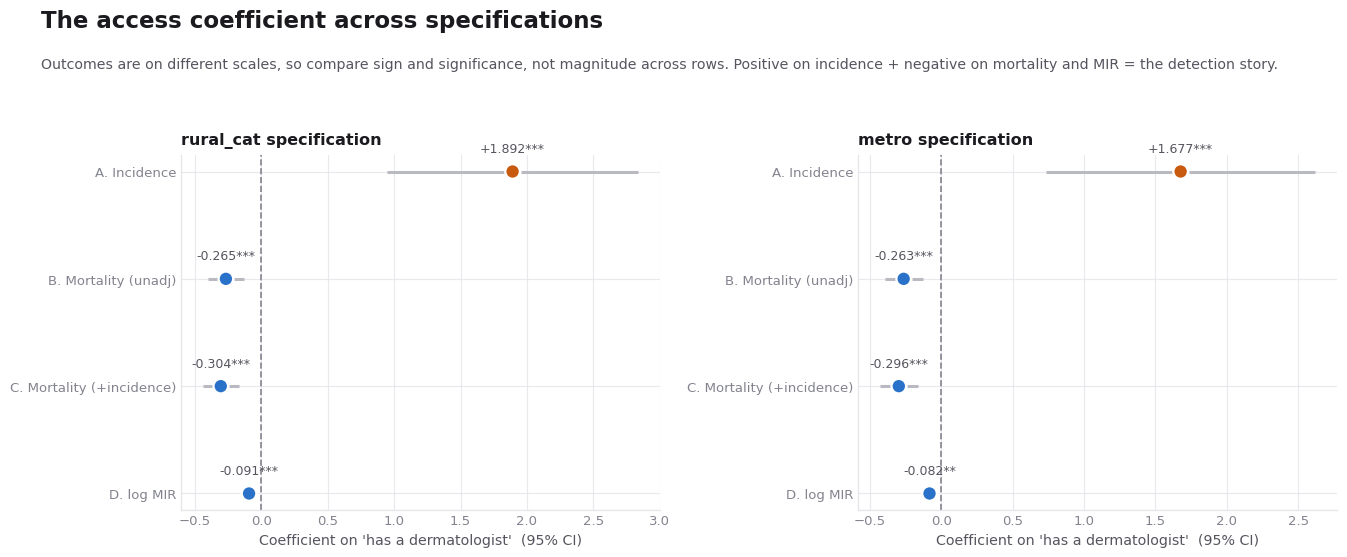

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.6), sharey=False)
for ax, spec in zip(axes, ["rural_cat", "metro"]):
    sub = res[(res.spec == spec) & (res.term == "anyderm")].copy()
    order = ["A. Incidence", "B. Mortality (unadj)", "C. Mortality (+incidence)", "D. log MIR"]
    sub["o"] = sub.model.map({m: i for i, m in enumerate(order)})
    sub = sub.sort_values("o")
    ypos = np.arange(len(sub))
    se = sub.coef.abs() / sub.t.abs().replace(0, np.nan)
    cols = [GRP[1][1] if c < 0 else GRP[0][1] for c in sub.coef]
    ax.axvline(0, color=MUTED, lw=1.2, ls="--", zorder=1)
    ax.errorbar(sub.coef, ypos, xerr=1.96*se, fmt="o", ms=10, mec="white", mew=1.6,
                elinewidth=2.2, capsize=0, ecolor="#b9b9c2", zorder=3, ls="none",
                color="none")
    ax.scatter(sub.coef, ypos, s=110, c=cols, edgecolors="white", linewidths=1.6, zorder=4)
    for yv, cf, pv in zip(ypos, sub.coef, sub.p):
        ax.annotate(f"{cf:+.3f}{stars(pv)}", (cf, yv), textcoords="offset points",
                    xytext=(0, 14), ha="center", fontsize=9, color=INK2)
    ax.set_yticks(ypos); ax.set_yticklabels(sub.model, fontsize=9.8)
    ax.invert_yaxis()
    _style(ax)
    ax.set_title(f"{spec} specification", fontsize=11.5, fontweight="bold",
                 color=INK, loc="left", pad=8)
    ax.set_xlabel("Coefficient on 'has a dermatologist'  (95% CI)",
                  fontsize=10.3, color=INK2)

fig.suptitle("The access coefficient across specifications", fontsize=16.5,
             fontweight="bold", x=.035, ha="left", y=.99, color=INK)
fig.text(.035, .905,
         "Outcomes are on different scales, so compare sign and significance, not magnitude "
         "across rows. Positive on incidence + negative on mortality and MIR = the detection story.",
         fontsize=10.2, color=INK2, ha="left", va="top")
plt.tight_layout(rect=[0, 0, 1, .87])
p = os.path.join(CONFIG["out_dir"], "fig_04_coefficient_plot.png")
fig.savefig(p, dpi=CONFIG["dpi"], facecolor="white"); print("  saved ->", p); plt.show()

## Step 19 · Export everything

In [26]:
res.to_csv(os.path.join(CONFIG["out_dir"], "ols_coefficients.csv"), index=False)
diag.to_csv(os.path.join(CONFIG["out_dir"], "spatial_diagnostics.csv"), index=False)
spatial.to_csv(os.path.join(CONFIG["out_dir"], "spatial_coefficients.csv"), index=False)

out = analysis.drop(columns="geometry").copy()
for k in ["mortality", "incidence", "derm", "mir", "bivariate"]:
    if f"lisa_{k}" in out.columns:
        out[f"lisa_{k}_label"] = out[f"lisa_{k}"].map(
            BV if k == "bivariate" else LISA_LABELS)
out.to_csv(os.path.join(CONFIG["out_dir"], "county_results.csv"), index=False)
print(f"county_results.csv: {len(out):,} counties x {out.shape[1]} columns")

acc_lo  = np.nanpercentile(a[CONFIG["derm_rate"]], 25)
mir_hi  = np.nanpercentile(a["mir"], 75)
priority = a[(a[CONFIG["derm_rate"]] <= acc_lo) & (a["mir"] >= mir_hi)].copy()
priority["access_gap_cluster"] = priority.get("lisa_bivariate", 0) == 2
cols = [c for c in ["FIPS", CONFIG["county"], CONFIG["state"], "rural_lab",
                    CONFIG["derm_count"], CONFIG["derm_rate"], CONFIG["any_derm"],
                    IR, MR, "mir", CONFIG["mort_event"], CONFIG["mort_denom"],
                    "access_gap_cluster"] if c in priority.columns]
priority = priority.sort_values(["access_gap_cluster", "mir"], ascending=[False, False])
priority[cols].to_csv(os.path.join(CONFIG["out_dir"], "priority_counties.csv"), index=False)
print(f"\nPRIORITY COUNTIES - bottom-quartile access AND top-quartile MIR")
print(f"  {len(priority):,} counties | {int(priority[CONFIG['mort_denom']].sum()):,} people "
      f"| {int(priority[CONFIG['mort_event']].sum()):,} melanoma deaths")
print(f"  by rurality: {priority.rural_lab.value_counts().to_dict()}")
display(priority[cols].head(20))

county_results.csv: 2,198 counties x 47 columns

PRIORITY COUNTIES - bottom-quartile access AND top-quartile MIR
  394 counties | 49,523,295 people | 2,845 melanoma deaths
  by rurality: {'Nonmetro (RUCC 4–7)': 252, 'Metro (RUCC 1–3)': 99, 'Completely rural (RUCC 8–9)': 43}


,FIPS,county,state,rural_lab,dermatologists,dermatology_rate,anyderm,ageadjustedrate,melanoma_mortality_rate,mir,melanoma_deaths,pop,access_gap_cluster
755,13087,Decatur County,georgia,Nonmetro (RUCC 4–7),0,0.0,0,16.600000,6.2,0.373494,8,71770,True
1590,40133,Seminole County,oklahoma,Nonmetro (RUCC 4–7),0,0.0,0,13.700000,4.4,0.321168,5,78494,True
2136,40121,Pittsburg County,oklahoma,Nonmetro (RUCC 4–7),0,0.0,0,23.900000,6.8,0.284519,15,156786,True
1055,40005,Atoka County,oklahoma,Completely rural (RUCC 8–9),0,0.0,0,23.900000,5.8,0.242678,4,51379,True
757,54027,Hampshire County,west virginia,Metro (RUCC 1–3),0,0.0,0,23.700001,5.7,0.240506,10,112605,True
1005,08117,Summit County,colorado,Nonmetro (RUCC 4–7),0,0.0,0,27.600000,6.3,0.228261,8,122445,True
192,40091,McIntosh County,oklahoma,Nonmetro (RUCC 4–7),0,0.0,0,19.000000,4.1,0.215789,6,68562,True
793,08093,Park County,colorado,Metro (RUCC 1–3),0,0.0,0,30.700001,6.5,0.211726,7,79599,True
1143,17159,Richland County,illinois,Nonmetro (RUCC 4–7),0,0.0,0,19.299999,3.9,0.202073,5,74365,True
1187,12063,Jackson County,florida,Nonmetro (RUCC 4–7),0,0.0,0,10.700000,2.1,0.196262,6,160266,True


In [27]:
import glob, shutil
readme = f"""MELANOMA / DERMATOLOGY / RURALITY - RESULTS
{'='*62}
Counties analysed : {len(a):,}
Geometry source   : {geo_source}
Projection        : Albers Equal Area (EPSG:5070)
Weights           : Queen contiguity, row-standardised, islands attached via KNN(1)
Permutations      : {P}
Population weight : {CONFIG['weight']}

DATA CAVEATS
  * {n_exact} exactly-duplicated rows dropped (upstream many-to-one merge, Georgia).
    FIX THIS UPSTREAM.
  * Mortality is CRUDE; incidence is AGE-ADJUSTED. Age structure is therefore an
    uncontrolled confounder of the mortality side. Crude-incidence checks included.
  * ~29% of US counties absent (suppressed incidence), non-randomly by rurality.
  * The true denominator behind dermatology_rate is not in the file; `pop` stands
    in for EB smoothing only.

GLOBAL MORAN'S I
{moran_tbl.to_string(index=False)}

ACCESS COEFFICIENT BY MODEL (rural_cat spec)
{res[(res.spec=='rural_cat') & (res.term=='anyderm')][['model','coef','p']].to_string(index=False)}

NEGATIVE BINOMIAL (Model E)
{nb_tbl.to_string(index=False)}

SIMPLE EFFECTS BY RURALITY (log MIR)
{simple_tbl.to_string(index=False)}

PRIORITY COUNTIES: {len(priority):,}

These are county-level (ecological) associations from cross-sectional data.
They do not license individual-level or causal conclusions.
"""
with open(os.path.join(CONFIG["out_dir"], "README.txt"), "w") as fh:
    fh.write(readme)
print(readme)

shutil.make_archive("melanoma_analysis_outputs", "zip", CONFIG["out_dir"])
print("\nFiles produced:")
for f in sorted(glob.glob(os.path.join(CONFIG["out_dir"], "*"))):
    print(f"  {os.path.basename(f):48s} {os.path.getsize(f)/1024:8.1f} KB")
try:
    from google.colab import files
    files.download("melanoma_analysis_outputs.zip")
except ImportError:
    print("\nNot in Colab - archive at", os.path.abspath("melanoma_analysis_outputs.zip"))

MELANOMA / DERMATOLOGY / RURALITY - RESULTS
Counties analysed : 2,198
Geometry source   : Census TIGER cb_2023_us_county_20m
Projection        : Albers Equal Area (EPSG:5070)
Weights           : Queen contiguity, row-standardised, islands attached via KNN(1)
Permutations      : 999
Population weight : pop

DATA CAVEATS
  * 110 exactly-duplicated rows dropped (upstream many-to-one merge, Georgia).
    FIX THIS UPSTREAM.
  * Mortality is CRUDE; incidence is AGE-ADJUSTED. Age structure is therefore an
    uncontrolled confounder of the mortality side. Crude-incidence checks included.
  * ~29% of US counties absent (suppressed incidence), non-randomly by rurality.
  * The true denominator behind dermatology_rate is not in the file; `pop` stands
    in for EB smoothing only.

GLOBAL MORAN'S I
                     Measure  Moran's I     z p (perm)   Pattern
         Mortality, raw rate     0.0437  3.04 0.0030** clustered
Mortality, EB (pop-weighted)     0.1739 11.62 0.0010** clustered
     M

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read these results

**Start with the coefficient plot (Step 18).** The signature to look for is a
**positive** access coefficient on incidence together with a **negative** one on
mortality and MIR. That combination is the detection story: dermatologists find more
melanoma, and the melanoma they find kills less often. A positive coefficient on
incidence alone would be alarming; alongside a negative MIR coefficient it is
reassuring.

**Then compare Model B with Model C.** If the access coefficient becomes *more*
negative once incidence is controlled, incidence was masking the association — access
counties looked worse than they were because they detect more disease. That is
negative confounding, and it is the expected pattern here.

**Then check Model E.** B–D put OLS on rates with radically different denominators,
which violates constant variance. E does not. Where E and C disagree, E is the more
defensible number.

### Limitations that belong in the write-up

1. **Crude vs age-adjusted mismatch.** Mortality is crude, incidence is age-adjusted.
   Older counties get inflated mortality with no corresponding inflation in the
   control. Merging in a percent-over-65 covariate, or an age-adjusted mortality rate,
   would close the biggest remaining hole in the design.
2. **Non-random suppression.** Roughly 29% of counties are absent, concentrated in
   small rural populations — precisely the counties an access study is about. Every
   estimate is conditional on being observed, and the completely-rural stratum is
   both small and a survivor subset. The rural interaction in particular rests on very
   few dermatologist-present rural counties.
3. **Over-adjustment remains possible.** Incidence is partly a mediator. Model C is
   reported *because* of that ambiguity, not despite it — treat C and D as bracketing
   rather than as point identification.
4. **Ecological inference.** Counties are not people. None of this establishes that
   an individual with less access dies more often.
5. **Reverse causation and timing.** Dermatologists locate where demand and income
   are, and 2019 workforce cannot have caused 2019–2023 deaths through a screening
   pathway that needs years to operate.
6. **MAUP.** County boundaries are administrative. Commuting zones or hospital service
   areas would give different numbers; re-running on an alternative geography is a
   genuine robustness check, not a formality.
7. **Punctured spatial surface.** The suppression holes break real adjacencies, which
   biases the weights matrix and therefore every spatial statistic to an unknown degree.

### Worth doing next

- Merge in **%65+, median income, uninsured rate, and a UV-exposure index**; UV is the
  main omitted confounder of incidence and is well measured at county level.
- Replace within-county counts with a **two-step floating catchment area (2SFCA)**
  accessibility measure — patients cross county lines for dermatology, and a binary
  in-county indicator understates access in tightly packed metro counties.
- Re-run against **Rook contiguity and KNN(6)** to confirm the clusters do not hinge
  on one adjacency definition.
- If stage-at-diagnosis is obtainable, model **stage** directly. It is the actual
  mechanism MIR is proxying, and it would turn this from an inference about survival
  into a measurement of it.